# **Sección 1. Datos, limpieza y análisis exploratorio de datos**

## **1.1 Contexto del problema**

El término **churn** o **fuga de clientes**, hace referencia al fenómeno mediante el cual un cliente termina su relación contractual con una empresa. En el sector de telecomunicaciones, donde los servicios suelen ofrecerse bajo modalidades de suscripción mensual o anual, el churn representa una de las principales preocupaciones operacionales y financieras: es ampliamente aceptado en la literatura de marketing que **adquirir un nuevo cliente cuesta varias veces más que retener uno existente**, y que pequeñas variaciones en la tasa de retención pueden tener efectos significativos sobre los ingresos a largo plazo.

Predecir el churn de manera anticipada permite a la empresa:

- Identificar segmentos de clientes con alta probabilidad de cancelar el servicio.
- Diseñar campañas de retención focalizadas (descuentos, mejoras de plan, atención personalizada).
- Detectar problemas estructurales en ciertos tipos de contrato, métodos de pago o servicios contratados.

Desde una perspectiva de ciencia de datos, se trata de un **problema de clasificación binaria supervisada**, donde la variable objetivo es `Churn` (`Yes` / `No`). El dataset utilizado contiene información demográfica del cliente, características del contrato, servicios contratados y montos de facturación, lo que lo hace especialmente adecuado para explorar la relación entre las decisiones comerciales del cliente y su propensión a abandonar la empresa.


## **1.2 Importación de librerías**

Para el desarrollo del análisis se utilizan las librerías estándar del ecosistema científico de Python: `pandas` y `numpy` para la manipulación de datos, `matplotlib` y `seaborn` para la visualización, y los módulos de `scikit-learn` correspondientes a preprocesamiento, *pipelines* y partición de datos.

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np
import joblib

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y partición de datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Manejo de advertencias y formato
import warnings
warnings.filterwarnings("ignore")

# Configuración estética para los gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

# Paleta de colores institucional para coherencia visual a lo largo del notebook
azul    = "#457b9d"   # clase No churn
rojo    = "#e63946"   # clase Yes churn
neutro  = "#a8dadc"
colors  = [azul, rojo]

# Configuración de pandas para mejor visualización de tablas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## **1.3 Carga del dataset**

El conjunto de datos se carga directamente desde el archivo CSV original distribuido por Kaggle. Se asume una estructura de carpetas en la que el archivo se encuentra en `../data/telco_churn.csv` relativo al notebook. Esta convención facilita la reproducibilidad y mantiene el código compatible con la organización del repositorio del proyecto.

In [2]:
# Carga del dataset desde el archivo CSV original
df = pd.read_csv("../data/telco_churn.csv")

print(f"Dataset cargado correctamente.")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

Dataset cargado correctamente.
Dimensiones: 7043 filas x 21 columnas


## **1.4 Exploración inicial del dataset**

Antes de cualquier transformación es necesario observar la estructura general del *DataFrame*: el tipo de cada variable, los rangos de las numéricas, la cardinalidad de las categóricas y la forma en que está codificada la variable objetivo. Esta inspección preliminar permite anticipar problemas (tipos incorrectos, valores codificados como texto, inconsistencias) que luego deberán tratarse en la etapa de limpieza.

### **1.4.1 Primeras y últimas observaciones**

In [3]:
# Primeras observaciones
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Últimas observaciones
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


La inspección visual de las primeras y últimas filas confirma que el archivo se cargó correctamente y que el separador es coherente. Cada fila representa un cliente único, identificado mediante la columna `customerID`. Se observan variables de naturaleza heterogénea: identificadores, atributos demográficos, indicadores de servicios contratados y variables de facturación. Llama la atención que columnas como `TotalCharges`, que conceptualmente debería ser numérica, aparecen con un formato que se examinará con más detalle más adelante.

### **1.4.2 Dimensiones, columnas y tipos de datos**

In [5]:
# Dimensiones
print("Dimensiones del dataset:", df.shape)
print(f"Número de observaciones: {df.shape[0]}")
print(f"Número de variables:     {df.shape[1]}")

Dimensiones del dataset: (7043, 21)
Número de observaciones: 7043
Número de variables:     21


In [6]:
# Listado de columnas
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [7]:
# Información estructural y completitud por columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


El dataset cuenta con **7 043 observaciones y 21 columnas**, lo cual constituye un volumen suficiente para un proyecto de clasificación binaria sin requerir técnicas avanzadas de manejo de grandes datos. La salida de `df.info()` revela una distribución mixta de tipos de datos:

- **Variables numéricas (`int64`, `float64`)**: `SeniorCitizen`, `tenure` y `MonthlyCharges`.
- **Variables tipo `object` (texto)**: el resto de las columnas, que incluyen tanto variables genuinamente categóricas (como `Contract` o `PaymentMethod`) como variables que conceptualmente son numéricas pero se almacenaron como texto (caso de `TotalCharges`).

Adicionalmente, en una primera lectura `df.info()` reporta que ninguna columna tiene valores nulos explícitos. Sin embargo, esto puede ser engañoso: como se verá más adelante, la columna `TotalCharges` contiene cadenas vacías que pandas no detecta como `NaN` y que requerirán un tratamiento específico. Este es un hallazgo característico del dataset Telco que debe abordarse con cuidado para no introducir sesgos en el modelado.

### **1.4.3 Estadísticos descriptivos**

In [8]:
# Resumen estadístico de variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


El resumen de las variables numéricas evidencia tres comportamientos distintos:

- **`SeniorCitizen`** es una variable binaria codificada como entero (0/1), con una media cercana a 0.16, lo que sugiere que aproximadamente el **16% de los clientes son adultos mayores**. Sus valores están restringidos a {0, 1}, por lo que más adelante será tratada como categórica binaria.
- **`tenure`** representa la antigüedad del cliente en meses y oscila entre 0 y 72, con una media cercana a 32 meses y una mediana de 29. La presencia de valores en 0 corresponde a clientes muy nuevos que aún no completan su primer ciclo de facturación, un detalle relevante que se retomará al analizar `TotalCharges`.
- **`MonthlyCharges`** se distribuye entre 18.25 y 118.75 dólares, con una media de aproximadamente 64.76. La amplia variabilidad refleja la diversidad de planes contratados.

In [9]:
# Resumen estadístico de variables categóricas
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


Para las variables tipo `object`, `describe` reporta el conteo de valores no nulos, el número de categorías únicas (`unique`), el valor más frecuente (`top`) y su frecuencia (`freq`). De esta inspección se desprenden varias observaciones:

- La variable `customerID` tiene **7 043 valores únicos**, exactamente el número de filas. Esto confirma que se trata de un identificador y no aporta valor predictivo.
- La variable `gender` cuenta con dos categorías (`Male`, `Female`) en proporciones similares.
- La variable objetivo `Churn` tiene dos categorías (`Yes`, `No`), con `No` como categoría predominante. Esto anticipa cierto desbalance que se cuantificará más adelante.
- Variables como `MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV` y `StreamingMovies` muestran tres categorías porque incluyen un valor adicional (`No internet service` o `No phone service`) que indica que el cliente no tiene contratado el servicio principal del que dependen.

### **1.4.4 Identificación de la variable objetivo**

La variable objetivo del problema es **`Churn`**, que indica si el cliente abandonó (`Yes`) o no (`No`) el servicio durante el último mes registrado. Se trata de una variable categórica dicotómica que será transformada a binaria numérica (1/0) para facilitar el modelado.

## **1.5 Diccionario preliminar de variables**

A continuación se presenta el diccionario de variables del dataset, que clasifica cada columna según su rol (identificador, predictor, objetivo) y su naturaleza estadística (numérica continua, numérica discreta, categórica nominal, binaria). Esta clasificación servirá de referencia para todas las decisiones de preprocesamiento posteriores.

In [10]:
# Diccionario de variables del dataset
diccionario = pd.DataFrame({
    "Variable": [
        "customerID", "gender", "SeniorCitizen", "Partner", "Dependents",
        "tenure", "PhoneService", "MultipleLines", "InternetService",
        "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
        "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling",
        "PaymentMethod", "MonthlyCharges", "TotalCharges", "Churn"
    ],
    "Rol": [
        "Identificador", "Predictor", "Predictor", "Predictor", "Predictor",
        "Predictor", "Predictor", "Predictor", "Predictor",
        "Predictor", "Predictor", "Predictor", "Predictor",
        "Predictor", "Predictor", "Predictor", "Predictor",
        "Predictor", "Predictor", "Predictor", "Variable objetivo"
    ],
    "Tipo": [
        "Identificador", "Categórica binaria", "Categórica binaria",
        "Categórica binaria", "Categórica binaria",
        "Numérica discreta", "Categórica binaria", "Categórica nominal",
        "Categórica nominal", "Categórica nominal", "Categórica nominal",
        "Categórica nominal", "Categórica nominal", "Categórica nominal",
        "Categórica nominal", "Categórica nominal", "Categórica binaria",
        "Categórica nominal", "Numérica continua", "Numérica continua",
        "Categórica binaria"
    ],
    "Grupo conceptual": [
        "ID", "Demográfico", "Demográfico", "Demográfico", "Demográfico",
        "Antigüedad", "Servicio contratado", "Servicio contratado",
        "Servicio contratado", "Servicio contratado", "Servicio contratado",
        "Servicio contratado", "Servicio contratado", "Servicio contratado",
        "Servicio contratado", "Facturación / Contrato", "Facturación / Contrato",
        "Facturación / Contrato", "Facturación", "Facturación",
        "Objetivo"
    ],
    "Descripción": [
        "Identificador único del cliente.",
        "Género del cliente (Male / Female).",
        "Indica si el cliente es adulto mayor (1) o no (0).",
        "Indica si el cliente tiene pareja (Yes / No).",
        "Indica si el cliente tiene dependientes a cargo (Yes / No).",
        "Antigüedad del cliente medida en meses.",
        "Indica si el cliente tiene servicio telefónico (Yes / No).",
        "Indica si tiene múltiples líneas telefónicas (Yes / No / No phone service).",
        "Tipo de servicio de internet (DSL / Fiber optic / No).",
        "Indica si tiene seguridad en línea contratada.",
        "Indica si tiene servicio de respaldo en línea.",
        "Indica si tiene protección de dispositivos.",
        "Indica si tiene soporte técnico contratado.",
        "Indica si tiene servicio de TV en streaming.",
        "Indica si tiene servicio de películas en streaming.",
        "Tipo de contrato (Month-to-month / One year / Two year).",
        "Indica si el cliente recibe facturación electrónica (Yes / No).",
        "Método de pago utilizado (cheque, tarjeta, transferencia, etc.).",
        "Cargo mensual facturado al cliente (en USD).",
        "Cargo total acumulado por el cliente (en USD).",
        "Indica si el cliente abandonó el servicio (Yes / No)."
    ]
})

pd.set_option("display.max_colwidth", None)
diccionario

,Variable,Rol,Tipo,Grupo conceptual,Descripción
0,customerID,Identificador,Identificador,ID,Identificador único del cliente.
1,gender,Predictor,Categórica binaria,Demográfico,Género del cliente (Male / Female).
2,SeniorCitizen,Predictor,Categórica binaria,Demográfico,Indica si el cliente es adulto mayor (1) o no (0).
3,Partner,Predictor,Categórica binaria,Demográfico,Indica si el cliente tiene pareja (Yes / No).
4,Dependents,Predictor,Categórica binaria,Demográfico,Indica si el cliente tiene dependientes a cargo (Yes / No).
5,tenure,Predictor,Numérica discreta,Antigüedad,Antigüedad del cliente medida en meses.
6,PhoneService,Predictor,Categórica binaria,Servicio contratado,Indica si el cliente tiene servicio telefónico (Yes / No).
7,MultipleLines,Predictor,Categórica nominal,Servicio contratado,Indica si tiene múltiples líneas telefónicas (Yes / No / No phone service).
8,InternetService,Predictor,Categórica nominal,Servicio contratado,Tipo de servicio de internet (DSL / Fiber optic / No).
9,OnlineSecurity,Predictor,Categórica nominal,Servicio contratado,Indica si tiene seguridad en línea contratada.


La tabla anterior agrupa las variables en cinco categorías conceptuales:

- **Demográficas**: `gender`, `SeniorCitizen`, `Partner`, `Dependents`. Describen al cliente como persona.
- **Antigüedad**: `tenure`. Mide el tiempo de permanencia y suele ser un predictor fuerte del churn.
- **Servicios contratados**: desde `PhoneService` hasta `StreamingMovies`. Describen el portafolio de servicios que el cliente consume.
- **Facturación y contrato**: `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`. Capturan la relación económica con la empresa.
- **Objetivo**: `Churn`. La variable a predecir.

Esta clasificación inicial guiará tanto el análisis exploratorio como la definición del preprocesador.

## **1.6 Revisión de calidad de datos**

En esta etapa se examina la calidad del conjunto de datos antes de aplicar cualquier transformación. Se verifican duplicados, valores nulos, valores únicos por columna y se atiende con especial detalle el caso conocido de la variable `TotalCharges`, que en este dataset suele almacenarse como texto y contener espacios en blanco.

### **1.6.1 Verificación de duplicados**

In [11]:
# Verificación de filas duplicadas
duplicados_total = df.duplicated().sum()
duplicados_id    = df["customerID"].duplicated().sum()

print(f"Número de filas completamente duplicadas: {duplicados_total}")
print(f"Número de customerID duplicados:          {duplicados_id}")

Número de filas completamente duplicadas: 0
Número de customerID duplicados:          0


El conjunto de datos **no contiene filas duplicadas** ni identificadores repetidos. Esto es coherente con la naturaleza del dataset, donde cada fila representa a un cliente distinto. La ausencia de duplicados garantiza que ninguna observación contribuirá de forma desproporcionada al entrenamiento.

### **1.6.2 Valores nulos**

In [12]:
# Conteo y porcentaje de valores faltantes por columna
nulos = df.isnull().sum()
porcentaje = (df.isnull().mean() * 100).round(2)

tabla_nulos = pd.DataFrame({
    "Valores faltantes": nulos,
    "Porcentaje (%)":    porcentaje
}).rename_axis("Variable").reset_index()

tabla_nulos

,Variable,Valores faltantes,Porcentaje (%)
0,customerID,0,0.0
1,gender,0,0.0
2,SeniorCitizen,0,0.0
3,Partner,0,0.0
4,Dependents,0,0.0
5,tenure,0,0.0
6,PhoneService,0,0.0
7,MultipleLines,0,0.0
8,InternetService,0,0.0
9,OnlineSecurity,0,0.0


A primera vista, `pandas.isnull()` no detecta valores faltantes en ninguna columna. No obstante, este resultado debe interpretarse con cautela: al estar la variable `TotalCharges` almacenada como texto, las cadenas vacías o con espacios en blanco no son contabilizadas como `NaN`. Esto motiva un análisis más cuidadoso en las secciones siguientes.

### **1.6.3 Valores únicos por columna**

In [13]:
# Cantidad de valores únicos por columna
unicos = pd.DataFrame({
    "Variable":             df.columns,
    "Valores únicos":       df.nunique().values,
    "Tipo de dato":         df.dtypes.astype(str).values
})
unicos = unicos.sort_values("Valores únicos").reset_index(drop=True)
unicos

,Variable,Valores únicos,Tipo de dato
0,Churn,2,object
1,gender,2,object
2,SeniorCitizen,2,int64
3,Partner,2,object
4,Dependents,2,object
5,PaperlessBilling,2,object
6,PhoneService,2,object
7,Contract,3,object
8,StreamingMovies,3,object
9,StreamingTV,3,object


La cantidad de valores únicos por columna confirma la naturaleza de cada variable:

- Variables binarias como `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling` y `Churn` tienen exactamente **dos valores únicos**.
- Variables categóricas con tres categorías incluyen `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` y `Contract`. La tercera categoría suele ser un valor del tipo *"No internet service"* o *"No phone service"*, que indica ausencia del servicio de soporte requerido.
- `PaymentMethod` cuenta con cuatro categorías: dos de pago automático (transferencia bancaria y tarjeta de crédito) y dos manuales (cheque electrónico y cheque por correo).
- `tenure` toma 73 valores enteros (de 0 a 72), `MonthlyCharges` y `TotalCharges` muestran muchos valores únicos, propios de variables continuas.
- `customerID` tiene 7 043 valores únicos, igual al número de filas, lo que confirma su rol como identificador.

### **1.6.4 Análisis específico de la variable `TotalCharges`**

La variable `TotalCharges` se almacena como texto en el archivo CSV original. Esto se debe a que ciertas filas contienen cadenas en blanco en lugar de valores numéricos, lo que impide que `pandas` las interprete como `float` durante la lectura. Antes de convertirla, se inspecciona el contenido para identificar dichos casos.

In [14]:
# Tipo de dato actual de TotalCharges
print(f"Tipo de dato de TotalCharges: {df['TotalCharges'].dtype}")

# Detección de cadenas vacías o con espacios
mask_vacios = df["TotalCharges"].astype(str).str.strip() == ""
print(f"Número de cadenas vacías en TotalCharges: {mask_vacios.sum()}")

Tipo de dato de TotalCharges: object
Número de cadenas vacías en TotalCharges: 11


In [15]:
# Inspección de las filas problemáticas
df.loc[mask_vacios, ["customerID", "tenure", "MonthlyCharges",
                     "TotalCharges", "Contract", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


La inspección revela un hallazgo muy particular: las **11 filas con `TotalCharges` en blanco corresponden a clientes con `tenure = 0`**. Es decir, son clientes recién ingresados que aún no han completado un ciclo de facturación, por lo que su monto acumulado todavía no está registrado. Este patrón no es aleatorio, sino estructural: refleja un estado válido de un cliente nuevo.

Esta interpretación es relevante porque condiciona la decisión de imputación: tratar estos valores como `NaN` y luego imputarlos sería equivalente a asignar a un cliente nuevo el monto acumulado de un cliente con varios años de antigüedad, lo cual es semánticamente incorrecto. Una alternativa razonable es **imputar dichos valores con 0**, ya que conceptualmente un cliente con `tenure = 0` aún no ha generado cargos acumulados. Esta es la decisión que se adopta en la siguiente sección, alineada con la práctica común documentada en la literatura sobre este dataset.

### **1.6.5 Conversión de `TotalCharges` a numérica**

In [16]:
# Conversión usando errors='coerce' para convertir las cadenas inválidas en NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(f"Tipo de dato tras la conversión: {df['TotalCharges'].dtype}")
print(f"Valores faltantes (NaN) generados: {df['TotalCharges'].isnull().sum()}")

Tipo de dato tras la conversión: float64
Valores faltantes (NaN) generados: 11


La conversión con `errors="coerce"` transforma todas las cadenas vacías en `NaN`, lo que confirma exactamente los 11 casos identificados previamente. Estos 11 valores faltantes representan apenas el **0.16%** del dataset, una proporción muy baja que cualquier estrategia razonable de imputación puede manejar sin distorsionar la distribución. La estrategia justificada (imputar con 0 dado que `tenure = 0`) se aplica en la sección siguiente como parte del proceso de limpieza.

## **1.7 Limpieza del dataset**

Con base en los hallazgos anteriores, se aplican las siguientes transformaciones de limpieza:

1. **Eliminación de `customerID`**: por tratarse de un identificador único sin valor predictivo, su inclusión en un modelo solo introduciría ruido o sobreajuste si se codifica indebidamente.
2. **Codificación binaria de la variable objetivo `Churn`**: se transforma `Yes` → 1 y `No` → 0, lo que permite trabajarla como una variable numérica en cualquier algoritmo de clasificación.
3. **Imputación de los 11 valores faltantes en `TotalCharges`** con el valor 0, dado que corresponden a clientes con `tenure = 0`.
4. **Verificación de consistencia** de las categorías para detectar variantes ortográficas o espacios en blanco no deseados.

In [17]:
# 1) Eliminación del identificador customerID del conjunto de predictores
df = df.drop(columns=["customerID"])

# 2) Codificación binaria de la variable objetivo
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# 3) Imputación de TotalCharges con 0 para clientes con tenure = 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verificación
print("customerID eliminado:", "customerID" not in df.columns)
print("Valores únicos en Churn:", sorted(df["Churn"].unique()))
print("NaN restantes en TotalCharges:", df["TotalCharges"].isnull().sum())
print(f"Dimensiones tras limpieza: {df.shape}")

customerID eliminado: True
Valores únicos en Churn: [0, 1]
NaN restantes en TotalCharges: 0
Dimensiones tras limpieza: (7043, 20)


In [18]:
# 4) Verificación de consistencia de categorías (espacios y mayúsculas)
categoricas = df.select_dtypes(include="object").columns

for col in categoricas:
    print(f"{col}: {sorted(df[col].unique())}")

gender: ['Female', 'Male']
Partner: ['No', 'Yes']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No', 'No phone service', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'No internet service', 'Yes']
OnlineBackup: ['No', 'No internet service', 'Yes']
DeviceProtection: ['No', 'No internet service', 'Yes']
TechSupport: ['No', 'No internet service', 'Yes']
StreamingTV: ['No', 'No internet service', 'Yes']
StreamingMovies: ['No', 'No internet service', 'Yes']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['No', 'Yes']
PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


La verificación muestra que todas las variables categóricas tienen sus categorías escritas de forma consistente, sin variantes por mayúsculas, espacios o errores tipográficos. No se requiere normalización adicional.

Tras la limpieza, el dataset queda con **20 columnas** (al haberse eliminado `customerID`) y **7 043 filas** sin valores faltantes. Las decisiones tomadas son trazables y se apoyan en el análisis previo, no en reglas arbitrarias.

## **1.8 Análisis exploratorio univariado**

En esta sección se examina la distribución individual de cada variable relevante. Se inicia con la variable objetivo `Churn` para evaluar el balance de clases, y se prosigue con las variables numéricas (`tenure`, `MonthlyCharges`, `TotalCharges`) mediante histogramas y diagramas de caja.

### **1.8.1 Distribución de la variable objetivo `Churn`**

In [19]:
# Tabla de frecuencias de la variable objetivo
freq = df["Churn"].value_counts().sort_index()
pct  = df["Churn"].value_counts(normalize=True).sort_index() * 100

tabla_target = pd.DataFrame({
    "Clase":          ["No churn (0)", "Churn (1)"],
    "Frecuencia":     freq.values,
    "Porcentaje (%)": pct.round(2).values
})
tabla_target

,Clase,Frecuencia,Porcentaje (%)
0,No churn (0),5174,73.46
1,Churn (1),1869,26.54


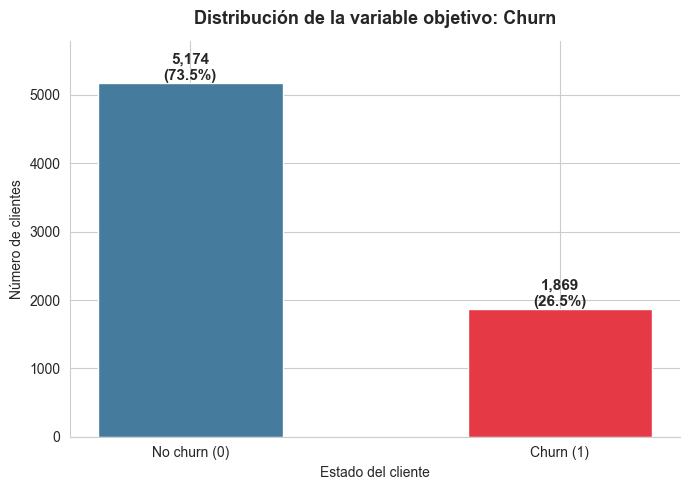

In [20]:
# Gráfico de la distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(["No churn (0)", "Churn (1)"], freq.values,
              color=colors, edgecolor="white", width=0.5)

for bar, val, p in zip(bars, freq.values, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val:,}\n({p:.1f}%)", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.set_title("Distribución de la variable objetivo: Churn", fontsize=13, pad=12)
ax.set_xlabel("Estado del cliente")
ax.set_ylabel("Número de clientes")
ax.set_ylim(0, freq.max() * 1.12)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

La distribución de la variable objetivo muestra un **desbalance moderado**: aproximadamente el **73.5%** de los clientes permanecen con la empresa, mientras que cerca del **26.5%** la abandonan. Este desbalance no es extremo pero sí lo suficientemente notable como para justificar dos decisiones metodológicas en las etapas siguientes:

1. **Estratificar la partición train/test** por la variable `Churn`, para preservar la proporción de clases en ambos subconjuntos.
2. **Priorizar métricas más informativas que el accuracy** durante la evaluación (recall, F1, AUC), dado que un clasificador ingenuo que prediga siempre "No churn" obtendría un accuracy del 73.5%, lo que no reflejaría utilidad real.

### **1.8.2 Distribución de las variables numéricas**

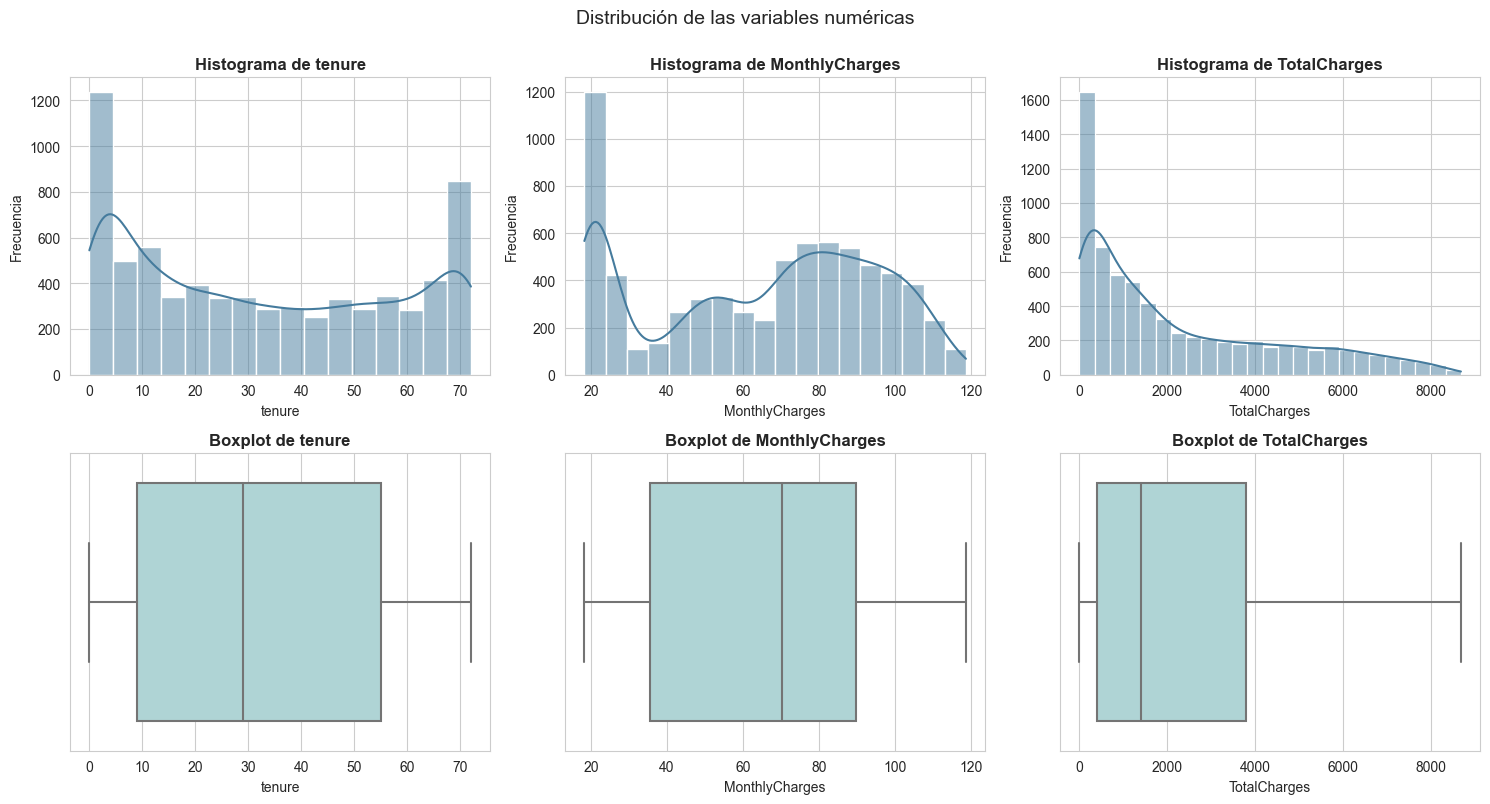

In [21]:
# Variables numéricas continuas para el análisis univariado
num_vars = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Distribución de las variables numéricas", fontsize=14, y=1.00)

# Histogramas con KDE en la primera fila
for i, col in enumerate(num_vars):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color=azul, edgecolor="white")
    axes[0, i].set_title(f"Histograma de {col}")
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Frecuencia")

# Boxplots en la segunda fila
for i, col in enumerate(num_vars):
    sns.boxplot(x=df[col], ax=axes[1, i], color=neutro)
    axes[1, i].set_title(f"Boxplot de {col}")
    axes[1, i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [22]:
# Asimetría y curtosis de las variables numéricas
df[num_vars].agg(["skew", "kurt"]).round(2).rename(
    index={"skew": "Asimetría", "kurt": "Curtosis"}
)

,tenure,MonthlyCharges,TotalCharges
Asimetría,0.24,-0.22,0.96
Curtosis,-1.39,-1.26,-0.23


El análisis univariado de las tres variables numéricas continuas revela patrones distintos:

- **`tenure`** presenta una distribución **fuertemente bimodal**, con concentraciones en los extremos: muchos clientes con muy pocos meses de antigüedad y otro grupo numeroso de clientes con permanencia cercana al máximo (72 meses). Esta forma sugiere que la base de clientes está compuesta principalmente por dos perfiles: clientes nuevos en proceso de evaluación del servicio y clientes consolidados de larga data. La asimetría es moderada y la curtosis indica una distribución relativamente plana, consecuencia de la bimodalidad observada.

- **`MonthlyCharges`** exhibe una distribución **multimodal**: se observa un pico claro en valores bajos (cerca de los 20 USD, asociado probablemente a clientes con servicios mínimos) y una concentración más amplia en valores medios y altos (entre 70 y 100 USD), correspondiente a clientes con paquetes de internet y servicios adicionales. Los boxplots no muestran *outliers* clásicos definidos por el criterio del IQR, ya que los valores se distribuyen en un rango cerrado y conocido.

- **`TotalCharges`** muestra una distribución **fuertemente sesgada a la derecha**, con la mayor parte de los clientes acumulando montos relativamente bajos y una larga cola hacia los altos. Esto es esperable, dado que `TotalCharges` es una función creciente del producto `tenure × MonthlyCharges`: clientes con menor antigüedad acumulan menos cargos. La asimetría positiva confirma el sesgo y, junto con el pico cercano a 0, refleja la presencia de muchos clientes nuevos.

Ninguna de las tres variables presenta valores extremos que ameriten tratamiento especial: los aparentes *outliers* de los boxplots corresponden a casos válidos del negocio (clientes de larga permanencia y alto consumo). La estrategia adecuada es escalarlas para que tengan magnitudes comparables, lo cual se hará en el preprocesador.

## **1.9 Análisis exploratorio bivariado**

A continuación se examina la relación entre las variables predictoras y la variable objetivo `Churn`. Para variables categóricas se utilizan **gráficos de barras normalizadas**, que permiten comparar proporciones de churn entre categorías independientemente del tamaño de cada grupo. Para variables numéricas se emplean **diagramas de caja** segmentados por la clase de `Churn`.

### **1.9.1 Churn según el tipo de contrato**

In [23]:
# Tabla cruzada normalizada entre Contract y Churn
cross_contract = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
cross_contract = cross_contract.round(2).rename(columns={0: "No churn (%)", 1: "Churn (%)"})
cross_contract

Churn,No churn (%),Churn (%)
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


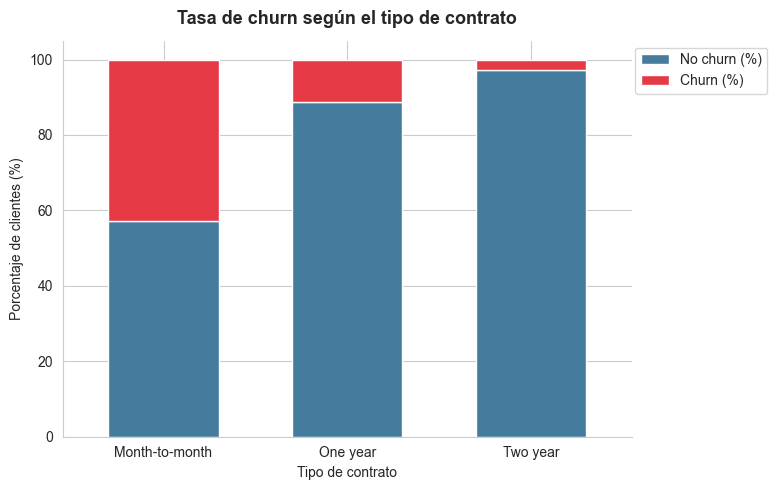

In [24]:
# Gráfico de barras apiladas normalizadas
fig, ax = plt.subplots(figsize=(8, 5))
cross_contract.plot(kind="bar", stacked=True, color=colors, ax=ax,
                    edgecolor="white", width=0.6)

ax.set_title("Tasa de churn según el tipo de contrato", fontsize=13, pad=12)
ax.set_xlabel("Tipo de contrato")
ax.set_ylabel("Porcentaje de clientes (%)")
ax.legend(title="", loc="upper right", bbox_to_anchor=(1.25, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

La relación entre el tipo de contrato y el churn es una de las más marcadas del dataset:

- Los clientes con **contrato mensual (`Month-to-month`)** presentan una tasa de churn cercana al **42.7%**, varias veces superior al promedio general (26.5%).
- Los clientes con **contrato anual (`One year`)** reducen drásticamente la tasa al **11.3%**.
- Los clientes con **contrato a dos años (`Two year`)** apenas alcanzan un **2.8%** de churn.

Esto evidencia una asociación clara: a mayor compromiso contractual, menor propensión a abandonar el servicio. Se trata, sin lugar a dudas, de uno de los predictores más informativos del problema. Esta variable es candidata natural a aparecer entre las más importantes en cualquier modelo entrenado posteriormente.

### **1.9.2 Churn según el método de pago**

In [25]:
cross_payment = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
cross_payment = cross_payment.round(2).rename(columns={0: "No churn (%)", 1: "Churn (%)"})
cross_payment.sort_values("Churn (%)", ascending=False)

Churn,No churn (%),Churn (%)
PaymentMethod,,
Electronic check,54.71,45.29
Mailed check,80.89,19.11
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24


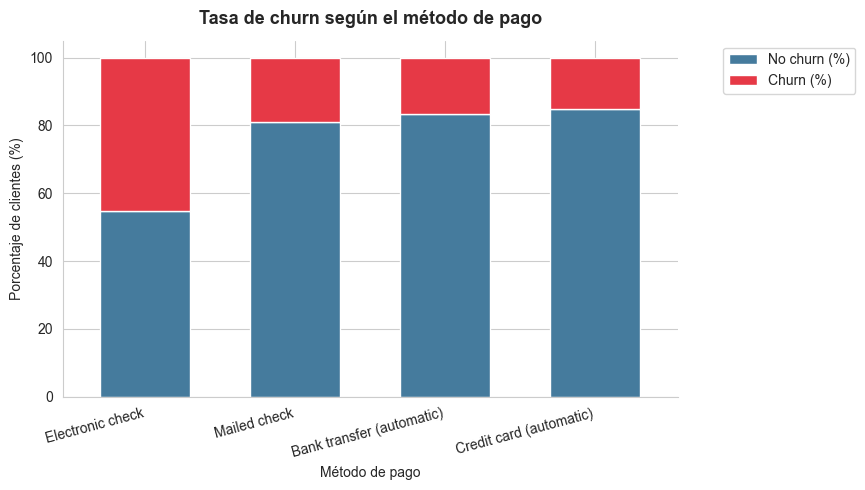

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
cross_payment.sort_values("Churn (%)", ascending=False).plot(
    kind="bar", stacked=True, color=colors, ax=ax, edgecolor="white", width=0.6
)

ax.set_title("Tasa de churn según el método de pago", fontsize=13, pad=12)
ax.set_xlabel("Método de pago")
ax.set_ylabel("Porcentaje de clientes (%)")
ax.legend(title="", loc="upper right", bbox_to_anchor=(1.30, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

El método de pago también muestra diferencias importantes:

- **`Electronic check`** concentra la tasa de churn más alta, superior al **45%**, lo cual la posiciona casi al doble del promedio general.
- Los métodos automáticos (**`Bank transfer (automatic)`** y **`Credit card (automatic)`**) tienen tasas notablemente más bajas, alrededor del **15-17%**.
- **`Mailed check`** se sitúa en una posición intermedia, alrededor del **19%**.

Una posible interpretación es que los clientes que utilizan métodos automatizados tienden a tener una relación más estable con la empresa (mayor compromiso, menor fricción operacional), mientras que los pagos manuales por cheque electrónico podrían correlacionarse con perfiles menos comprometidos. Conviene insistir en que se trata de **asociaciones**, no de relaciones causales.

### **1.9.3 Churn según el tipo de servicio de internet**

In [27]:
cross_internet = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
cross_internet = cross_internet.round(2).rename(columns={0: "No churn (%)", 1: "Churn (%)"})
cross_internet

Churn,No churn (%),Churn (%)
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


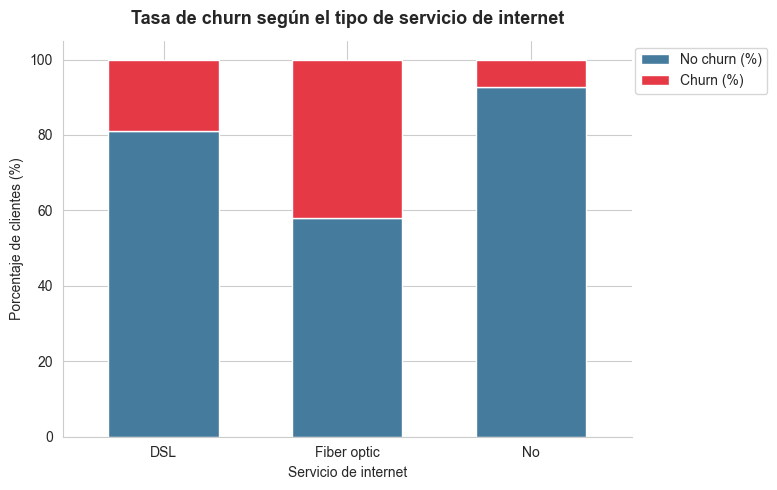

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
cross_internet.plot(kind="bar", stacked=True, color=colors, ax=ax,
                    edgecolor="white", width=0.6)

ax.set_title("Tasa de churn según el tipo de servicio de internet", fontsize=13, pad=12)
ax.set_xlabel("Servicio de internet")
ax.set_ylabel("Porcentaje de clientes (%)")
ax.legend(title="", loc="upper right", bbox_to_anchor=(1.25, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

La variable `InternetService` revela un patrón llamativo:

- Los clientes con **fibra óptica** son los que más abandonan el servicio (~**41.9%**), a pesar de ser el servicio teóricamente superior.
- Los clientes con **DSL** presentan una tasa intermedia (~**19.0%**).
- Quienes **no tienen servicio de internet** muestran la tasa más baja (~**7.4%**).

Este resultado, aparentemente contraintuitivo, es uno de los hallazgos más documentados en este dataset. Posibles explicaciones incluyen problemas de calidad o estabilidad del servicio de fibra, expectativas más altas en clientes que pagan más, o factores asociados a la competencia del mercado. En cualquier caso, los modelos posteriores deberán capturar adecuadamente este efecto.

### **1.9.4 Churn según `tenure`**

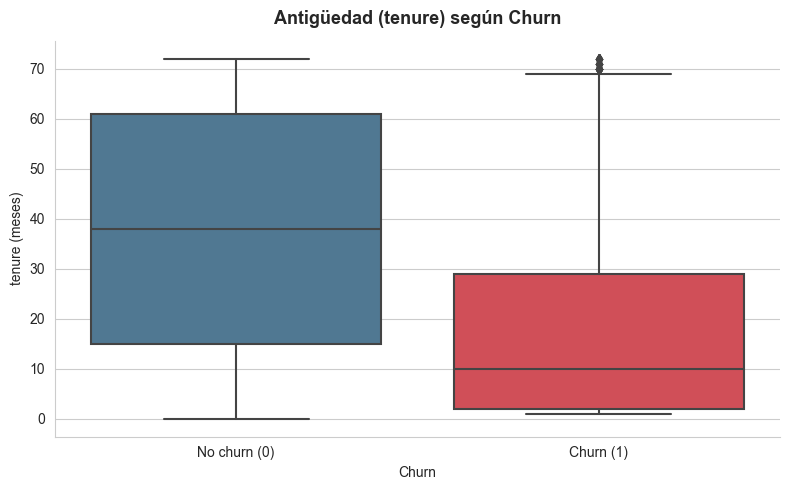

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="Churn", y="tenure", data=df, palette=colors, ax=ax)

ax.set_title("Antigüedad (tenure) según Churn", fontsize=13, pad=12)
ax.set_xlabel("Churn")
ax.set_ylabel("tenure (meses)")
ax.set_xticklabels(["No churn (0)", "Churn (1)"])
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

El boxplot revela una **separación marcada** entre los dos grupos:

- Los clientes que **abandonan** (`Churn = 1`) presentan una antigüedad notablemente baja: la mediana se ubica en torno a los 10 meses y el tercer cuartil rara vez supera los 30 meses.
- Los clientes que **permanecen** (`Churn = 0`) muestran una distribución mucho más amplia, con mediana cerca de los 38 meses y un tercer cuartil próximo al máximo (72 meses).

Esta diferencia es coherente con la intuición: los clientes nuevos están en una fase de evaluación del servicio y presentan mayor riesgo de abandono, mientras que los clientes consolidados tienden a mantenerse. La variable `tenure` es, junto con `Contract`, uno de los predictores más fuertes del problema.

### **1.9.5 Churn según `MonthlyCharges`**

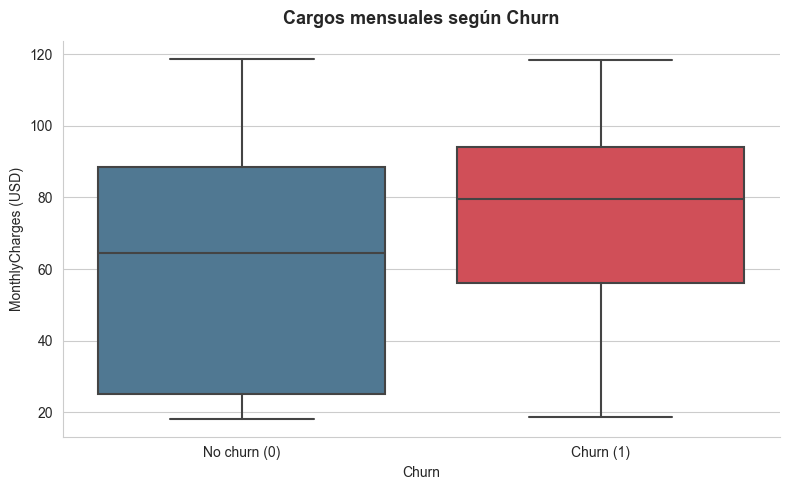

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette=colors, ax=ax)

ax.set_title("Cargos mensuales según Churn", fontsize=13, pad=12)
ax.set_xlabel("Churn")
ax.set_ylabel("MonthlyCharges (USD)")
ax.set_xticklabels(["No churn (0)", "Churn (1)"])
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

Los clientes que abandonan tienden a tener **cargos mensuales más altos** que quienes se mantienen. La mediana del grupo `Churn = 1` se sitúa por encima de la del grupo `Churn = 0`, y la distribución completa se desplaza hacia valores superiores. Esto es consistente con la observación previa sobre el servicio de fibra óptica, que es el más caro y el que concentra la mayor proporción de cancelaciones. La interpretación combinada de ambas variables sugiere que los planes de mayor costo, especialmente los asociados a fibra, son los que enfrentan mayores desafíos de retención.

### **1.9.6 Churn según `TotalCharges`**

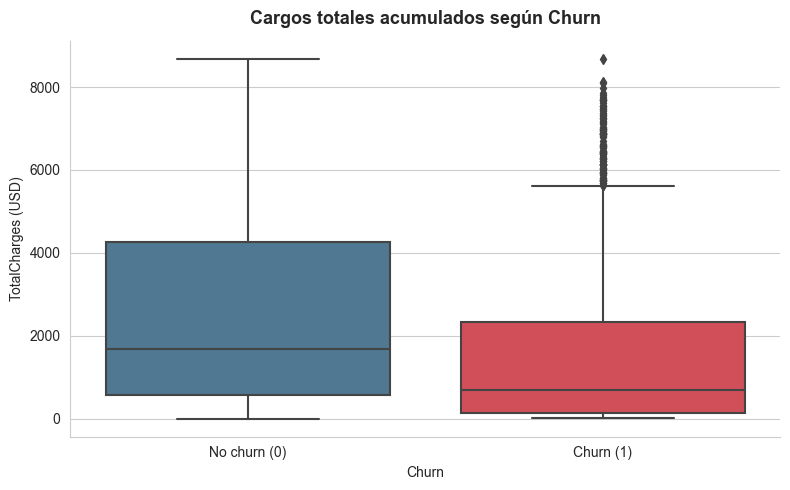

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="Churn", y="TotalCharges", data=df, palette=colors, ax=ax)

ax.set_title("Cargos totales acumulados según Churn", fontsize=13, pad=12)
ax.set_xlabel("Churn")
ax.set_ylabel("TotalCharges (USD)")
ax.set_xticklabels(["No churn (0)", "Churn (1)"])
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

El comportamiento de `TotalCharges` con respecto a `Churn` es consistente con el de `tenure`: los clientes que abandonan muestran montos totales acumulados **considerablemente más bajos**, dado que han pertenecido menos tiempo a la empresa y, por tanto, han acumulado menos cargos. Existe una relación natural entre `tenure`, `MonthlyCharges` y `TotalCharges` (este último es aproximadamente el producto de los otros dos), lo que se traducirá en una correlación alta entre las tres variables, fenómeno que se cuantifica en la siguiente sección.

## **1.10 Matriz de correlación**

La matriz de correlación se construye sobre las variables numéricas del dataset, junto con la variable objetivo `Churn` ya codificada como binaria. Se incluye también `SeniorCitizen`, que es numérica binaria. Para las demás variables categóricas no se calcula correlación de Pearson, pues no es la métrica adecuada para datos no ordinales; su análisis ya se abordó mediante tablas cruzadas y gráficos de barras.

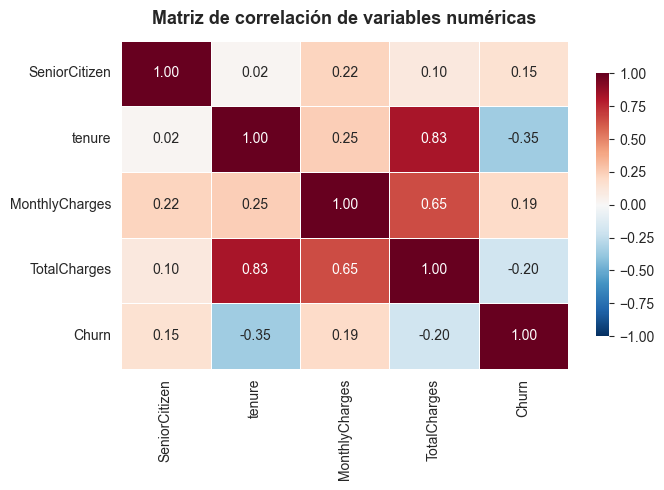

In [32]:
# Matriz de correlación con variables numéricas y binarias numéricas
vars_correlacion = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
corr_matrix = df[vars_correlacion].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, fmt=".2f", linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title("Matriz de correlación de variables numéricas", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

La matriz de correlación resume varias observaciones importantes:

- **`tenure` y `TotalCharges`** presentan una correlación **muy alta y positiva** (≈ 0.83), lo cual era esperado, dado que `TotalCharges` se construye como una función creciente del tiempo de permanencia. Esta colinealidad no impide el modelado, pero deberá tenerse presente al interpretar la importancia de variables: ambas codifican información parcialmente redundante.

- **`MonthlyCharges` y `TotalCharges`** también muestran correlación positiva moderada (≈ 0.65), por la misma razón estructural.

- **`tenure` y `Churn`** mantienen una correlación **negativa** (≈ −0.35): a mayor antigüedad, menor probabilidad de abandono, en concordancia con el análisis bivariado anterior.

- **`MonthlyCharges` y `Churn`** muestran una correlación positiva débil (≈ 0.19), coherente con la observación de que los planes más caros tienden a tener mayores tasas de churn.

- **`SeniorCitizen` y `Churn`** exhiben una correlación positiva débil (≈ 0.15), sugiriendo que los adultos mayores tienen una tendencia ligeramente superior a abandonar el servicio.

Es importante recalcar que la **correlación no implica causalidad**: las relaciones identificadas son puramente asociativas y reflejan patrones del conjunto de datos, no relaciones causales del fenómeno de churn. Determinar causalidad requeriría diseños experimentales o cuasi-experimentales que están fuera del alcance de este proyecto.

## **1.11 Preparación inicial para modelado**

Habiendo concluido el análisis exploratorio y la limpieza, se procede a dejar el dataset listo para las siguientes secciones del proyecto. Los pasos que se ejecutan a continuación son:

1. Separación entre variables predictoras (`X`) y variable objetivo (`y`).
2. Identificación de columnas numéricas y categóricas.
3. Construcción de un **preprocesador unificado** mediante `ColumnTransformer`, que aplique:
   - **Numéricas**: imputación con la mediana + estandarización con `StandardScaler`.
   - **Categóricas**: imputación con la moda + codificación con `OneHotEncoder(handle_unknown="ignore")`.
4. Partición estratificada en entrenamiento y prueba (80/20).

Es fundamental aclarar que el preprocesador **se construye pero no se ajusta** en esta sección. El ajuste se realizará dentro de un `Pipeline` en la sección de modelado, junto con el clasificador. Esta práctica evita el llamado **data leakage**: si se imputaran o escalaran los datos antes de la partición, las estadísticas del conjunto de prueba contaminarían las del conjunto de entrenamiento, llevando a estimaciones de desempeño optimistas e irreales.

### **1.11.1 Separación de `X` e `y`**

In [33]:
# Separación entre predictores y variable objetivo
X = df.drop(columns=["Churn"])
y = df["Churn"]

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"Distribución de y: {y.value_counts(normalize=True).round(4).to_dict()}")

Dimensiones de X: (7043, 19)
Dimensiones de y: (7043,)
Distribución de y: {0: 0.7346, 1: 0.2654}


### **1.11.2 Identificación de columnas numéricas y categóricas**

Para construir el preprocesador es necesario distinguir las columnas según su naturaleza. Las columnas numéricas son `tenure`, `MonthlyCharges` y `TotalCharges`. La variable `SeniorCitizen`, aunque almacenada como entero, es conceptualmente binaria y se trata como categórica para que `OneHotEncoder` la procese de forma uniforme con el resto de variables binarias del dataset.

In [34]:
# Identificación automática
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [col for col in X.columns if col not in num_cols]

print(f"Columnas numéricas ({len(num_cols)}):")
for c in num_cols:
    print(f"   - {c}")

print(f"\nColumnas categóricas ({len(cat_cols)}):")
for c in cat_cols:
    print(f"   - {c}")

Columnas numéricas (3):
   - tenure
   - MonthlyCharges
   - TotalCharges

Columnas categóricas (16):
   - gender
   - SeniorCitizen
   - Partner
   - Dependents
   - PhoneService
   - MultipleLines
   - InternetService
   - OnlineSecurity
   - OnlineBackup
   - DeviceProtection
   - TechSupport
   - StreamingTV
   - StreamingMovies
   - Contract
   - PaperlessBilling
   - PaymentMethod


### **1.11.3 Construcción del preprocesador**

In [35]:
# Pipeline para variables numéricas
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Pipeline para variables categóricas
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer que aplica cada pipeline a su grupo correspondiente
preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# lo guardamos en un archivo joblib para usarlo en el notebook de modelado
joblib.dump(preprocessor, "../app/preprocessor.joblib")

print("Preprocesador definido correctamente.")
preprocessor

Preprocesador definido correctamente.


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

El `ColumnTransformer` encapsula todo el preprocesamiento en un único objeto reutilizable. Esto facilita su integración con cualquier estimador en las secciones siguientes mediante un `Pipeline` con la forma `Pipeline([("preprocessor", preprocessor), ("clf", modelo)])`, garantizando que las transformaciones se ajusten **únicamente** con los datos de entrenamiento dentro de cada *fold* de validación cruzada.

### **1.11.4 Partición estratificada en entrenamiento y prueba**

In [36]:
# Partición estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape} | y_test:  {y_test.shape}")
print(f"\nProporción de churn en entrenamiento: {y_train.mean():.4f}")
print(f"Proporción de churn en prueba:        {y_test.mean():.4f}")

# lo guardamos en archivos joblib para usarlos en el notebook de modelado
joblib.dump(X_train, "../data/X_train.joblib")
joblib.dump(X_test, "../data/X_test.joblib")
joblib.dump(y_train, "../data/y_train.joblib")
joblib.dump(y_test, "../data/y_test.joblib")

X_train: (5634, 19) | y_train: (5634,)
X_test:  (1409, 19) | y_test:  (1409,)

Proporción de churn en entrenamiento: 0.2654
Proporción de churn en prueba:        0.2654


['../data/y_test.joblib']

Se utiliza `stratify=y` para asegurar que la proporción de cada clase se preserve tanto en el conjunto de entrenamiento como en el de prueba. Esta decisión es especialmente importante en problemas de clasificación con clases desbalanceadas: sin estratificación, una partición aleatoria podría producir un conjunto de prueba con una proporción de churn significativamente distinta a la del conjunto general, comprometiendo la validez de las estimaciones de desempeño.

La salida confirma que las proporciones de churn en los dos subconjuntos son prácticamente idénticas (cerca de **26.5%** en ambos), lo cual valida la correcta aplicación de la estratificación. Se utiliza también `random_state=42` para asegurar la reproducibilidad de los resultados.

## **1.12 Conclusión parcial del análisis exploratorio**

El análisis exploratorio del dataset **Telco Customer Churn** permite extraer las siguientes conclusiones que sintetizan el estado del problema antes del modelado:

**Estado general del dataset.** El conjunto cuenta con 7 043 observaciones y 21 columnas (20 predictoras tras eliminar el identificador). El volumen es adecuado para entrenar modelos de clasificación supervisada sin requerir técnicas de muestreo especiales. Cada fila representa un cliente único, y no existen duplicados.

**Calidad de los datos.** La calidad general es alta. El único problema relevante de integridad fue la presencia de 11 cadenas vacías en `TotalCharges`, almacenadas originalmente como texto, asociadas todas ellas a clientes con `tenure = 0`. Tras convertir la variable a numérica y aplicar imputación con 0 (justificada por el hecho de que un cliente sin antigüedad no ha generado cargos acumulados), el dataset queda completamente libre de valores faltantes. No se detectaron outliers que ameriten tratamiento, ya que los valores extremos en variables como `tenure` o `MonthlyCharges` corresponden a casos válidos del negocio.

**Variables más relacionadas con el churn.** El análisis bivariado y la matriz de correlación identifican varios predictores con asociación clara con la variable objetivo:

- **`Contract`**: contratos mensuales presentan tasas de churn muy superiores (~42.7%) frente a contratos a uno (~11.3%) o dos años (~2.8%).
- **`tenure`**: a menor antigüedad, mayor probabilidad de abandono. Existe una separación visible entre las distribuciones de los dos grupos.
- **`InternetService`**: los clientes con fibra óptica muestran una tasa de churn muy elevada (~41.9%), pese a ser el servicio premium.
- **`PaymentMethod`**: el cheque electrónico se asocia a tasas de churn cercanas al 45%, considerablemente mayores que los métodos automáticos.
- **`MonthlyCharges`**: los cargos mensuales más altos están asociados a tasas de abandono superiores.

Estas asociaciones son consistentes entre sí y construyen un perfil tentativo del cliente con alta propensión al churn: cliente nuevo, con contrato mensual, servicio de fibra óptica, pago manual y cargo mensual elevado.

**Decisiones de limpieza tomadas.** Las decisiones aplicadas, todas justificadas a partir de la evidencia explorada, fueron:

1. Eliminación de la columna identificadora `customerID`.
2. Conversión de `TotalCharges` de tipo texto a numérico mediante `pd.to_numeric` con `errors="coerce"`.
3. Imputación de los 11 valores resultantes en `TotalCharges` con 0, dado que corresponden a clientes con `tenure = 0`.
4. Codificación binaria de la variable objetivo `Churn` (`Yes` = 1, `No` = 0).
5. Verificación de consistencia categórica, sin necesidad de normalizaciones adicionales.

**Preparación para las siguientes secciones.** El dataset queda particionado en conjuntos de entrenamiento (80%) y prueba (20%) mediante muestreo estratificado, preservando la proporción de la clase positiva (~26.5%) en ambos subconjuntos. Se construyó un `ColumnTransformer` que aplicará imputación con mediana y estandarización a las variables numéricas, e imputación con moda y codificación *one-hot* a las categóricas. Este preprocesador no fue ajustado en esta sección, sino que se entrega listo para integrarse dentro de un `Pipeline` en la sección de modelado, garantizando un flujo libre de *data leakage*. Con esto, las siguientes etapas del proyecto pueden proceder sobre un cimiento sólido y reproducible.

# **Sección 2. Entrenamiento y evaluación de modelos**

n esta sección se presenta el entrenamiento de los cuatro modelos: ``Random Forest``, ``XGBoost``, ``CatBoost`` y ``LightGBM``, cuyo rendimiento se evaluará mediante curvas ROC, matrices de confusión y métricas de clasificación. Para el ajuste de hiperparámetros se utilizará GridSearchCV con validación cruzada StratifiedKFold de 5 pliegues, garantizando que la proporción entre clases se mantenga en cada partición dado el desbalance presente en el dataset.

## **2.1 Importación de librerías**

Antes de iniciar, cargamos las librerías a utilizar en todo este proceso de modelado, de la optimización de hiperparámetros y el uso de validación cruzada.

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score,  recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import joblib
import pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
import seaborn as sns


import time
import ctypes

# Cargamos los archivos joblib con los datos preprocesados
X_train = joblib.load("../data/X_train.joblib")
X_test = joblib.load("../data/X_test.joblib")
y_train = joblib.load("../data/y_train.joblib")
y_test = joblib.load("../data/y_test.joblib")
preprocesador = joblib.load("../data/preprocessor.joblib")

# definimos semilla para reproducibilidad
RANDOM_STATE = 42

## **2.2 Validación cruzada**

Por instrucciones del ejercicio se utiliza una partición estratificada de 5 pliegues mediante ``StratifiedKFold``. Esta elección es acertada dado el desbalance evidente en el dataset, ya que al mantener la proporción de clases en cada pliegue se garantizan resultados más representativos y sin ningún tipo de sesgo o filtración de datos entre conjuntos.

In [2]:
# definimos la estrategia de validación cruzada estratificada a usar
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## **2.3 Construcción del Pipeline**

Dado que ya se realizó todo el preprocesamiento previo, se procede con el modelado. Para esto se construye un Pipeline que permite aplicar transformaciones como el escalado y la codificación de variables categóricas de manera ordenada y sin riesgo de fuga de datos entre el conjunto de entrenamiento y prueba, tal como se vio en clase. Para su construcción se aprovecha el preprocesador definido anteriormente.

In [3]:

# dependiendo del modelo que se quiera usar, se puede cambiar el nombre del modelo y el modelo en sí
def construir_pipeline(modelo, nombre_modelo, preprocessor):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', modelo)
    ])
    return pipeline

Ahora, crearemos varias funciones reutilizables antes de entrenar el modelo para hacer el proceso más eficiente y evitar hacer código demás.

In [4]:
def evaluar_modelo(modelo, nombre, X_test, y_test):
    
    y_pred = modelo.predict(X_test) # lo que predice el modelo
    y_prob = modelo.predict_proba(X_test)[:, 1] # probabilidades
    
    # calculamos todas las métricas
    return {
        "Modelo": nombre,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_pred, zero_division=0),
        "Test ROC AUC": roc_auc_score(y_test, y_prob),
        
    }  

Esta función se usa para evaluar el modelo bajo distintas métricas. Es útil para comparar que tan bien generaliza nuestro modelo y comparar con las métricas obtenidas en validación cruzada

In [5]:
def entrenar_modelo(model, nombre_modelo, preproccesor, param_grid, X_train, y_train, X_test, y_test, cv, n_jobs):
    
    # guardamos los resultados 
    resultados_totales = {}
    
    
    # construimos el pipeline
    pipeline = construir_pipeline(model, nombre_modelo, preproccesor)
    
    # aplicamos GridSearchCV para encontrar los mejores hiperparámetros
    grid_search = GridSearchCV(
        estimator=pipeline,  # le pasamos el pipeline
        param_grid=param_grid, # espacio de búsqueda
        scoring="roc_auc", # métrica a optimizar
        cv=cv, # validación cruzada
        n_jobs=n_jobs,  # usa todos los cores
        verbose=1
    )
    
    # medimos tiempo
    inicio = time.time()
    grid_search.fit(X_train, y_train)
    tiempo = time.time() - inicio
    
    # hacemos la evaluación para el mejor modelo 
    evaluacion = evaluar_modelo(
            grid_search.best_estimator_,
            f"Grid Search - {nombre_modelo}",
            X_test,
            y_test
        
    )
    
    # guardamos los resultados en una lista
    resultados_totales[nombre_modelo] = {
         **evaluacion,
         "Mejores Hiperparámetros": grid_search.best_params_,
            "Mejor ROC AUC CV": grid_search.best_score_,
         "Tiempo (s)": tiempo,
            "Iteraciones": len(grid_search.cv_results_['params']),
        }
    
    print(f"Tiempo: {tiempo:.2f}s | Mejor ROC AUC CV: {grid_search.best_score_:.4f}")
    print(f"Mejores params: {grid_search.best_params_}")
    
    # retornamos lista con resultados
    return resultados_totales, grid_search.best_estimator_

La anterior función utiliza `GridSearchCV` como método de optimización de hiperparámetros, el cual recibira un espacio de búsqueda predefinido para cada modelo y el pipeline. Posteriormente, se entrena y se evalua con la función ya descrita. Todo estos resultados se guardan en una lista para visualizarlo de la mejor manera.

Por último, definiremos las siguientes funciones para hacer la matriz de confusión y la curva ROC:

In [72]:
def graficar_resultados(y_test, predicciones, probabilidades, nombre_modelo):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # matriz de confusión
    matriz = confusion_matrix(y_test, predicciones)
    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=["No Churn (0)", "Churn (1)"]  # cambiado
    )
    cm_display.plot(cmap='Blues', values_format='d', ax=axes[0])
    axes[0].set_title(f"Matriz de Confusión — {nombre_modelo}")

    # curva ROC
    fpr, tpr, _ = roc_curve(y_test, probabilidades)
    auc = roc_auc_score(y_test, probabilidades)
    axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc:.4f}")
    axes[1].plot([0, 1], [0, 1], color="orange", linestyle="--", lw=2, label="Clasificador aleatorio")
    axes[1].set_xlabel("Tasa de Falsos Positivos")
    axes[1].set_ylabel("Tasa de Verdaderos Positivos")
    axes[1].set_title(f"Curva ROC — {nombre_modelo}")
    axes[1].grid(True)
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

## **2.4 Entrenamiento modelos**

Ahora si, con las funciones definidas y los pipelines construidos, se procederá al entrenamiento de los modelos asignados. Para cada uno se definira un espacio de búsqueda de hiperparámetros, teninendo en cuenta tanto las recomendaciones encontradas en la literatura y la estructura del dataset. La métrica a optimizar será ROC AUC, ya que permite evaluar la capacidad del modelo para diferenciar entre ambas clases y mantener un equilibrio general entre las métricas de clasificación.

En este caso, dado al desbalance que se presenta en el dataset se incorporarán parámetros como `class_weight`, `scale_pos_weight` y `auto_class_weights` en los modelos correspondientes, con el fin de otorgar una mayor importancia a la clase minoritaria. Esto permite que, aunque la optimización se realice sobre `roc_auc`, no se vea excesivamente afectado el desempeño de otras métricas relevante como el `recall`, el cual resulta especialmente importante en este contexto, pues representa la capacidad del modelo para identificar correctamente a los clientes con mayor probabilidad de abandono (churn).

### **2.4.1 Random Forest**

Primero, definiremos el espacio de búsqueda definido para este modelo. Utilizaremos parámetros, aparte de los convencionales como `n_estimators` (número de árboles) o `max_depth` (máxima profundidad permitida), los recomendados en la asignación: `min_samples_split`, tamaño mínimo para dividir nodos/interiores/hoja; `min_samples_leaf`, mínimo de datos necesarios en cada hoja; `max_features`, máximo de features por split; `bootstrap`, método de bootstrapping; y `criterion`, función de criterio (gini/entropy).

In [ ]:
param_grid_rf = {
    'model__n_estimators': [100, 200, 300], 
    'model__max_depth': [10, 20, None],
    "model__min_samples_split":[2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
    "model__bootstrap": [True, False],
    "model__criterion": ["gini", "entropy"]
}

# llamamos al modelo
RandomForest_Model = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')

Se limita n_estimators hasta 300 porque con este tamaño de datos más árboles podría aumentar el costo computacional sin mejoras significativas en el rendimiento. Se incluye max_depth=None para capturar interacciones entre variables fuertes como `Contract` y `tenure`. Valores de min_samples_leaf hasta 4 ayudan a evitar sobreajuste en la clase minoritaria, y se prueban tanto gini como entropy.

In [45]:
ctypes.windll.kernel32.SetThreadExecutionState(0x80000002)
print("Modo suspensión desactivado") # evitamos que el computador se apague durante el entrenamiento del modelo

resultados_rf, mejor_rf = entrenar_modelo(RandomForest_Model, "Random Forest", preprocesador, param_grid_rf, X_train, y_train, X_test, y_test, cv, -1)


# guardamos el modelo
joblib.dump(mejor_rf, "../data/mejor_rf.joblib")

ctypes.windll.kernel32.SetThreadExecutionState(0x80000000)
print("Modo suspensión restaurado")

Modo suspensión desactivado
Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Tiempo: 487.40s | Mejor ROC AUC CV: 0.8468
Mejores params: {'model__bootstrap': True, 'model__criterion': 'entropy', 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Modo suspensión restaurado


Observamos que el modelo tardó aproximadamente 8 minutos y 7 segundos en completar el entrenamiento y búsqueda de hiperparámetros, obteniendo un ``ROC AUC`` en validación cruzada de 0.8468. En este caso, el mejor modelo utilizó 200 árboles (``n_estimators = 200``), el criterio de entropía (``entropy``) para la división de nodos, aplicó bootstrap, y estableció una profundidad máxima de 10 (``max_depth = 10``). Además, seleccionó sqrt como número de variables a considerar en cada división, con un mínimo de 4 observaciones por hoja y 2 observaciones para realizar una partición.

### **2.4.1 XGBoost**

De manera análoga, se utilizarán parámetros recomendados en la asignación: `subsample`, proporción de muestras; `colsample_bytree`, proporción de variables por árbol; `gamma`, criterio mínimo para dividir nodos; `min_child_weight`, peso mínimo en nodos hoja; `reg_alpha` y `reg_lambda`, regularización L1/L2; y `scale_pos_weight`, definida en el modelo.

In [53]:
param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__reg_lambda': [1, 5],
    'model__reg_alpha': [0, 0.1],
    'model__gamma': [0, 0.1],
    'model__min_child_weight': [1, 3]
}


neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos


# llamamos al modelo
xgb_model = XGBClassifier(
    random_state = RANDOM_STATE,
    scale_pos_weight = scale_pos_weight
)

El espacio de búsqueda para XGBoost considera tanto los hiperparámetros convencionales como los recomendados en la asignación. subsample y colsample_bytree se prueban desde 0.8 para no perder demasiada información dado el tamaño del dataset. gamma se mantiene en valores bajos ya que los datos no presentan ruido excesivo. Para la regularización, reg_alpha parte desde 0 (sin regularización L1) hasta valores moderados, mientras que reg_lambda arranca en 1, que es el default de XGBoost

In [54]:
ctypes.windll.kernel32.SetThreadExecutionState(0x80000002)
print("Modo suspensión desactivado") # evitamos que el computador se apague durante el entrenamiento del modelo

resultados_xgb, mejor_xgb = entrenar_modelo(xgb_model, "XGBoost", preprocesador, param_grid_xgb, X_train, y_train, X_test, y_test, cv, -1)

# guardamos el modelo
joblib.dump(mejor_xgb, "../data/mejor_xgb.joblib")

ctypes.windll.kernel32.SetThreadExecutionState(0x80000000)
print("Modo suspensión restaurado")

Modo suspensión desactivado
Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
Tiempo: 169.39s | Mejor ROC AUC CV: 0.8500
Mejores params: {'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 100, 'model__reg_alpha': 0.1, 'model__reg_lambda': 5, 'model__subsample': 0.8}
Modo suspensión restaurado


Analizando el entrenamiento del modelo, vemos que tardo muchos menos que `Random Forest`, puesto que fueron 6 minutos de diferencia, aparte de eso, obtuvo un ROC AUC en validación cruzada de 0.85. En este caso, el mejor modelo utilizó 100 árboles (n_estimators = 100), una tasa de aprendizaje baja de 0.05 (learning_rate), y una profundidad máxima de 3 (max_depth = 3), sugiriendo un modelo relativamente conservador. Además, empleó un muestreo del 80% de filas y columnas (subsample = 0.8, colsample_bytree = 0.8), sin penalización por gamma, con regularización L1 = 0.1 y L2 = 5, favoreciendo una mejor generalización del modelo.

### **2.4.3 CatBoost**

El modelo CatBoost destaca entre los otros con una particularidad, no es necesario aplicar un preprocesamiento previo a las variables categóricas, dado que internamente este se encarga de hacerlo. Sin embargo, por términos de comparación se realizara de igual manera que los otros para efectos más justos en la comparación. Acá también se integraron los hiperparámetros sugeridos para este modelo.

In [56]:
param_grid_cat = {
    'model__iterations': [100, 200, 300],
    'model__depth': [4, 6, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__l2_leaf_reg': [1, 3, 5, 10],
    'model__subsample': [0.8, 1.0],
    'model__random_strength': [0.5, 1.0]
}

# definimos el modelo y aprovechamos para utilizar la gpu
cat_model = CatBoostClassifier(random_seed = RANDOM_STATE, auto_class_weights='Balanced', verbose=0)

Para CatBoost se exploran los hiperparámetros recomendados. l2_leaf_reg en valores bajos dado que el dataset no es muy ruidoso. subsample se mantiene desde 0.8 para no perder información. Se mantiene una profundidad y una tasa de aprendizaje similar al de los anteriores modelos entrenados.

In [57]:
ctypes.windll.kernel32.SetThreadExecutionState(0x80000002)
print("Modo suspensión desactivado") # evitamos que el computador se apague durante el entrenamiento del modelo

resultados_cat, mejor_cat = entrenar_modelo(cat_model, "CatBoost", preprocesador, param_grid_cat, X_train, y_train, X_test, y_test, cv, -1)

# guardamos el modelo
joblib.dump(mejor_cat, "../data/mejor_cat.joblib")

ctypes.windll.kernel32.SetThreadExecutionState(0x80000000)
print("Modo suspensión restaurado")

Modo suspensión desactivado
Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Tiempo: 379.34s | Mejor ROC AUC CV: 0.8506
Mejores params: {'model__depth': 4, 'model__iterations': 200, 'model__l2_leaf_reg': 5, 'model__learning_rate': 0.05, 'model__random_strength': 1.0, 'model__subsample': 0.8}
Modo suspensión restaurado


Observamos que el modelo tardó aproximadamente 6 minutos con 19 segundos en completar el entrenamiento y búsqueda de hiperparámetros, donde obtuvo un `ROC AUC` en validación cruzada de 0.8506, el cual es ligeramente superior al de Random Forest. El mejor modelo utilizó 200 iteraciones, una profundidad de 4 y una taza de aprendizaje de 0.05, no se fue por valores muy extremos. Además, empleó una regularización L2 de 5 y un subsample de 0.8, buscando mejorar la capacidad de generalización.

### **2.4.4 LightGBM**

Por último, probaremos el modelo LightGBM que destaca por su velocidad y eficiencia. También se utilizaron todos los parámetros sugeridos en la asignación.

In [59]:
param_grid_lgbm = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [-1, 10, 20],
    'model__learning_rate': [0.05, 0.1],
    'model__num_leaves': [31, 63],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__min_child_samples': [20, 50],
    'model__reg_alpha': [0, 0.1],
    'model__reg_lambda': [1, 5]
}

# llamamos al modelo
lgbm_model = LGBMClassifier(
    random_state = RANDOM_STATE,
    class_weight='balanced'
)

Para LightGBM se mantienen rangos similares a los modelos anteriores en n_estimators y max_depth para garantizar consistencia en la comparación. min_child_samples se prueba hasta 50, que con 7K filas ya es bastante restrictivo. subsample y colsample_bytree se mantienen desde 0.8 para no perder información. Para la regularización, reg_alpha parte desde 0 hasta valores moderados y reg_lambda arranca en su default.

In [60]:
ctypes.windll.kernel32.SetThreadExecutionState(0x80000002)
print("Modo suspensión desactivado") # evitamos que el computador se apague durante el entrenamiento del modelo

resultados_lgbm, mejor_lgbm = entrenar_modelo(lgbm_model, "LightGBM", preprocesador, param_grid_lgbm, X_train, y_train, X_test, y_test, cv, -1)

# guardamos el modelo
joblib.dump(mejor_lgbm, "../data/mejor_lgbm.joblib")

ctypes.windll.kernel32.SetThreadExecutionState(0x80000000)
print("Modo suspensión restaurado")

Modo suspensión desactivado
Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 670
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Tiempo: 653.68s | Mejor ROC AUC CV: 0.8467
Mejores params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 10, 'model__min_child_samples': 20, 'model__n_estimators': 100, 'model__num_leaves': 31, 'model__reg_alpha': 0.1, 'model__reg_lambda': 5, 'model__subsample': 0.8}
Modo suspensión restaurado


Se observa que el modelo duro aproximadamente 10 minutos con 53 segundos en completar el entrenamiento, siendo el que más tiempo ha tardado. Alcanzo un `ROC AUC` en validación cruzada de 0.8467, un desempeño similar al obtenido con Random Forest. En este caso, el mejor modelo utilizó 100 árboles, una tasa de aprendizaje de 0.05 y una profundidad máxima de 10. Además, empleó un muestreo del 80% de filas y columnas (subsample = 0.8, colsample_bytree = 0.8), junto con regularización L1 = 0.1 y L2 = 5, buscando reducir el sobreajuste y mejorar la generalización del modelo.

## **2.5 Evaluación por modelo**

Dado que ya tenemos los modelos entrenados, ahora procederemos a evaluar su rendimiento a partir del score de sus métricas, matriz de confusión y curva ROC.

### **2.5.1 Random forest**

In [ ]:
resultados_rf_tabla = pd.DataFrame(resultados_rf).T
display(resultados_rf_tabla.iloc[:, :-1].style.hide(axis="index"))

Modelo,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Mejores Hiperparámetros,Mejor ROC AUC CV,Tiempo (s)
Grid Search - Random Forest,0.770050,0.549020,0.748663,0.633484,0.841796,"{'model__bootstrap': True, 'model__criterion': 'entropy', 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}",0.846786,487.397619


Analizando el desempeño del modelo Random Forest, se observa que obtuvo un ``ROC AUC`` de 0.8467 en validación cruzada y 0.8417 en test, una diferencia aproximadamente de 0.005 puntos. Lo anterior sugiere una buena capacidad de generalización del modelo y apenas un leve indicio de overfitting, el cual parece mantenerse controlado. Ahora, en términos de detectar si un cliente realmente desea abandonar el servicio, el modelo muestra un comportamiento moderado: presenta una precisión relativamente baja (0.5490) pero un recall moderado (0.7486), lo que indica que, de cada 10 clientes que realmente abandonan, el modelo logra identificar aproximadamente 7, mientras que cerca de 3 no son detectados. Por último, se observa un F1-score moderado (0.63), lo que sugiere un equilibrio aceptable entre precisión y recall, aunque todavía existe margen de mejora en la reducción de falsos positivos.

Ahora, procedamos a graficar las curvas ROC y la matriz de confusión para un análisis más profundo:

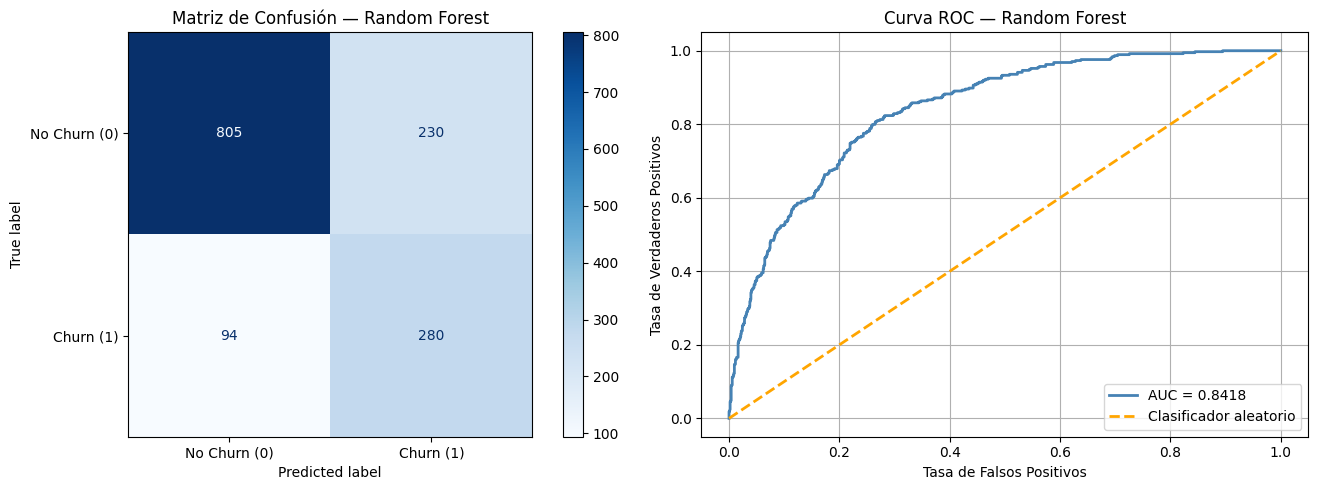

In [62]:
graficar_resultados(
    y_test,
    mejor_rf.predict(X_test),
    mejor_rf.predict_proba(X_test)[:, 1],
    "Random Forest"
)

A partir de la matriz de confusión, se observa que el modelo presentó 94 falsos negativos, es decir, clientes que realmente querían abandonar el servicio pero no fueron detectados por el modelo. Por otro lado, se identifican 230 falsos positivos, correspondientes a clientes que realmente no querían abandonar, pero fueron clasificados como posibles casos de churn. Esto refleja una precisión moderada, ya que una proporción importante de clientes clasificados como abandono realmente no pertenecían a esta categoría. Como se mencionó anteriormente, existe una diferencia entre precision y recall, lo cual puede estar influenciado por el uso de parámetros de balanceo de clases, que suelen favorecer la detección de la clase minoritaria y, por ende, mejorar métricas como el recall, aunque en ocasiones sacrificando precisión.

Al observar la curva ROC, se evidencia un AUC = 0.8418, lo que indica un buen desempeño del modelo para distinguir entre clientes que desean abandonar el servicio y aquellos que no. En términos prácticos, esto sugiere que el modelo tiene aproximadamente un 84% de capacidad discriminativa entre ambas clases. Además, la curva se aproxima relativamente rápido a la esquina superior izquierda, indicando una buena capacidad para identificar clientes con riesgo de abandono manteniendo una tasa moderada de falsos positivos.

### **2.5.2 XGBoost**

In [55]:
# tablamos los resultados
resultados_xgb_tabla = pd.DataFrame(resultados_xgb).T
resultados_xgb_tabla

,Modelo,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Mejores Hiperparámetros,Mejor ROC AUC CV,Tiempo (s),Iteraciones
XGBoost,Grid Search - XGBoost,0.7445,0.511945,0.802139,0.625,0.848224,"{'model__colsample_bytree': 0.8, 'model__gamma...",0.849952,169.388615,1152


Analizando el desempeño del modelo XGBoost, se observa que obtuvo un ROC AUC de 0.8499 en validación cruzada y 0.8482 en test, presentando una diferencia mínima de aproximadamente 0.0017 puntos. Esto sugiere una muy buena capacidad de generalización del modelo, con apenas un leve indicio de overfitting, prácticamente despreciable. En cuanto al desempeño para detectar clientes que desean abandonar el servicio, el modelo presenta una precisión moderada-baja (0.5119), indicando que una proporción importante de clientes clasificados como churn realmente no pertenecen a esta categoría. Sin embargo, el modelo logra un recall alto (0.8021), lo que significa que detecta aproximadamente 8 de cada 10 clientes que realmente desean abandonar el servicio, siendo una característica favorable en este contexto de negocio. Finalmente, se observa un F1-score de 0.6250, considerado moderado, lo que refleja el compromiso existente entre precision y recall, especialmente debido al énfasis del modelo en maximizar la detección de clientes con riesgo de abandono (por scale_pos_weight).

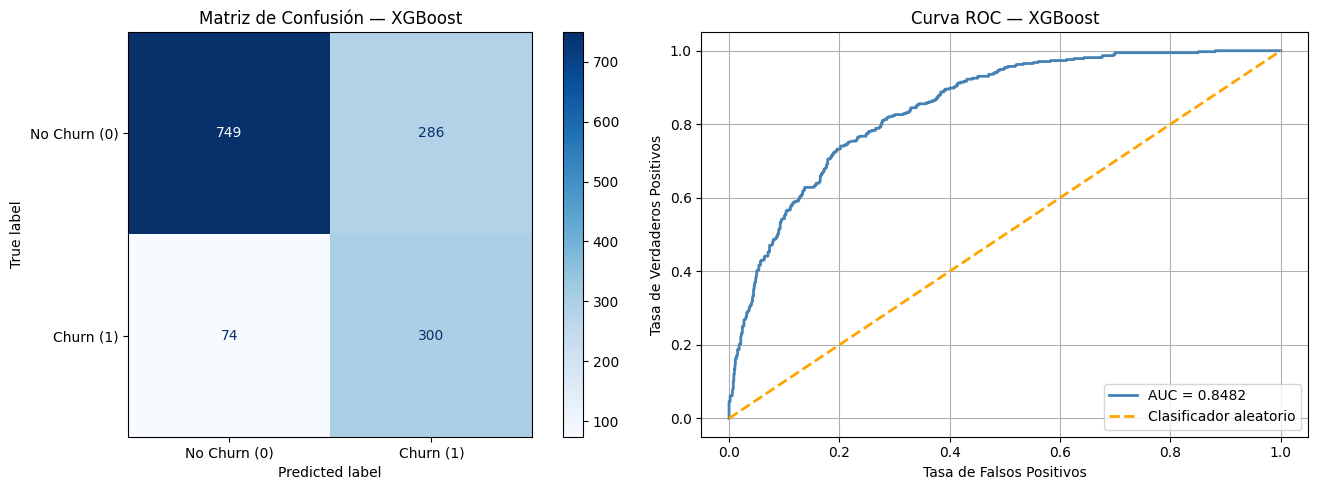

In [63]:
graficar_resultados(
    y_test,
    mejor_xgb.predict(X_test),
    mejor_xgb.predict_proba(X_test)[:, 1],
    "XGBoost"
)

En la matriz de confusión se evidencia que de 1409 clientes en el conjunto de prueba, 749 clientes que no querían abandonar el servicio fueron identificados corretamente, mientras que 300 clientes que realmente deseaban abandonar fueron detectados exitosamente. Asimismo, se observa que 74 clientes con intención de abandono no fueron detectados por el modelo (falsos negativos) y 286 clientes fueron clasificados incorrectamente como posibles casos de abandono, cuando realmente no lo eran (falsos positivos). En este caso, el modelo logra detectar gran parte de los clientes con riesgo de churn, presentando pocos falsos negativos. Aunque existen algunos falsos positivos, en este contexto suelen representar un costo menor para la empresa, ya que una intervención preventiva sobre un cliente que realmente no iba a abandonar el servicio suele ser menos costosa que perder un cliente potencialmente valioso.

De la curva ROC se logra evidenciar un AUC = 0.8482, ligeramente superior al de Random Forest, lo que indica un buen desempeño del modelo para distinguir entre clientes que desean abandonar el servicio y aquellos que no. En términos prácticos, esto sugiere que el modelo tiene aproximadamente un 84% de capacidad discriminativa entre ambas clases, semejante al de Random Forest.

### **2.5.3 CatBoost**

In [58]:
# tablamos los resultados
resultados_cat_tabla = pd.DataFrame(resultados_cat).T
resultados_cat_tabla

,Modelo,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Mejores Hiperparámetros,Mejor ROC AUC CV,Tiempo (s),Iteraciones
CatBoost,Grid Search - CatBoost,0.7445,0.511986,0.799465,0.624217,0.846108,"{'model__depth': 4, 'model__iterations': 200, ...",0.850559,379.338475,288


Es claro que ya se empieza a evidenciar un patrón relativamente estable en los resultados obtenidos, pues no existe una brecha significativa entre el desempeño de los distintos modelos evaluados. En términos generales, la mayoría presenta métricas bastante similares entre sí, lo que sugiere que el dataset podría tener un límite en la capacidad de separación entre clases. En el caso de CatBoost, se obtuvo un ROC AUC de 0.8461, indicando una buena capacidad del modelo para diferenciar entre clientes que desean abandonar el servicio y aquellos que no. Asimismo, presentó un recall alto (0.7994), logrando detectar aproximadamente 8 de cada 10 clientes que realmente desean abandonar, aunque con una precision relativamente baja (0.5120), mostrando nuevamente el compromiso entre ambas métricas. Estos resultados son bastante similares al obtenido con XGBoost.

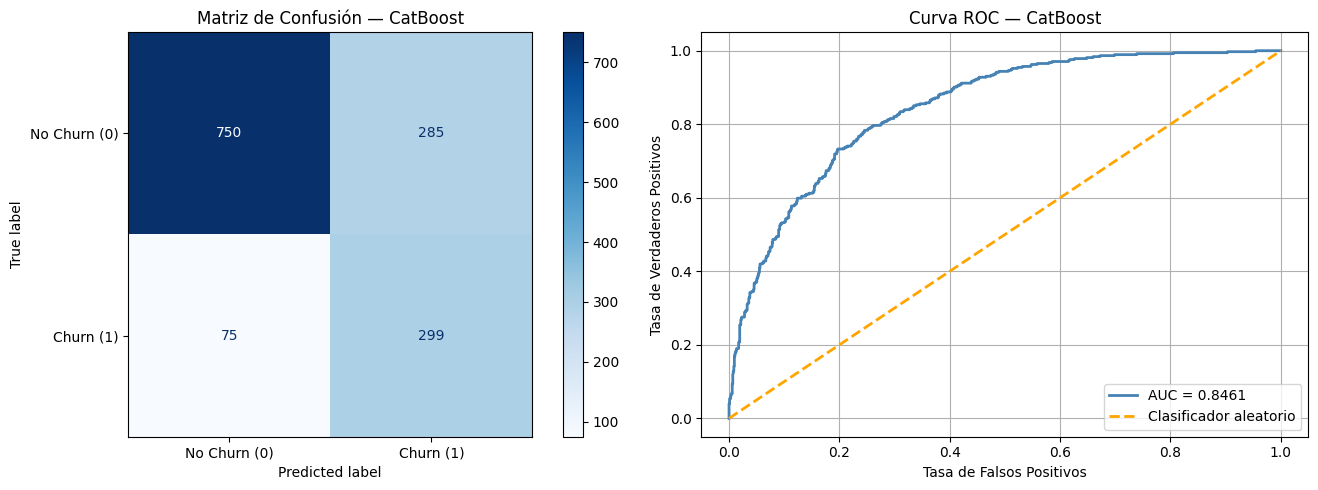

In [71]:
graficar_resultados(
    y_test,
    mejor_cat.predict(X_test),
    mejor_cat.predict_proba(X_test)[:, 1],
    "CatBoost"
)

En base a la matriz de confusión se observa valores similares al modelo de XBoost. Para este modelo, de 1409 clientes se detectaron 750 que no querían abandonar el servicio correctamente, mientras que 299 clientes fueron detectados de manera exitosa. De igual manera, se observa que 75 clientes con intención de abandono no fueron detectados por el modelo (falsos negativos) y 285 clientes fueron clasificados incorrectamente como posibles casos de abandono, cuando realmente no lo eran (falsos positivos), una cantidad considerable. En este caso, el modelo logra detectar gran parte de los clientes con riesgo de churn, presentando pocos falsos negativos, semejante a XGBoost.

Al observar la curva ROC, se evidencia un AUC = 0.8461, indicando una buena capacidad del modelo para discriminar entre clientes que desean abandonar el servicio y aquellos que no. Además, la curva se aproxima relativamente rápido hacia la esquina superior izquierda, sugiriendo una buena capacidad de detección de clientes con churn manteniendo una tasa moderada de falsos positivos.

### **2.5.4 LightGBM**

In [61]:
# tablamos los resultados
resultados_lgbm_tabla = pd.DataFrame(resultados_lgbm).T
resultados_lgbm_tabla

,Modelo,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Mejores Hiperparámetros,Mejor ROC AUC CV,Tiempo (s),Iteraciones
LightGBM,Grid Search - LightGBM,0.757984,0.52973,0.786096,0.632939,0.844818,"{'model__colsample_bytree': 0.8, 'model__learn...",0.846724,653.675391,1152


Analizando el desempeño del modelo LightGBM, se observa que obtuvo un ROC AUC de 0.8467 en validación cruzada y 0.8448 en test, presentando una diferencia mínima de aproximadamente 0.002 puntos, lo que sugiere una buena capacidad de generalización del modelo y poco indicio de sobreajuste. En cuanto a su capacidad para detectar clientes con intención de abandonar el servicio, el modelo presenta un recall alto (0.7861), indicando que logra identificar aproximadamente 8 de cada 10 clientes que realmente desean abandonar. Por otro lado, muestra una precision moderada-baja (0.5297), evidenciando la presencia de falsos positivos. Finalmente, se obtuvo un F1-score de 0.6329, ligeramente superior al de algunos modelos evaluados previamente, reflejando un equilibrio moderado entre precision y recall. Además, el tiempo de entrenamiento fue de aproximadamente 653.68 segundos (10 minutos y 54 segundos), siendo uno de los tiempos computacionales más altos entre los modelos evaluados.

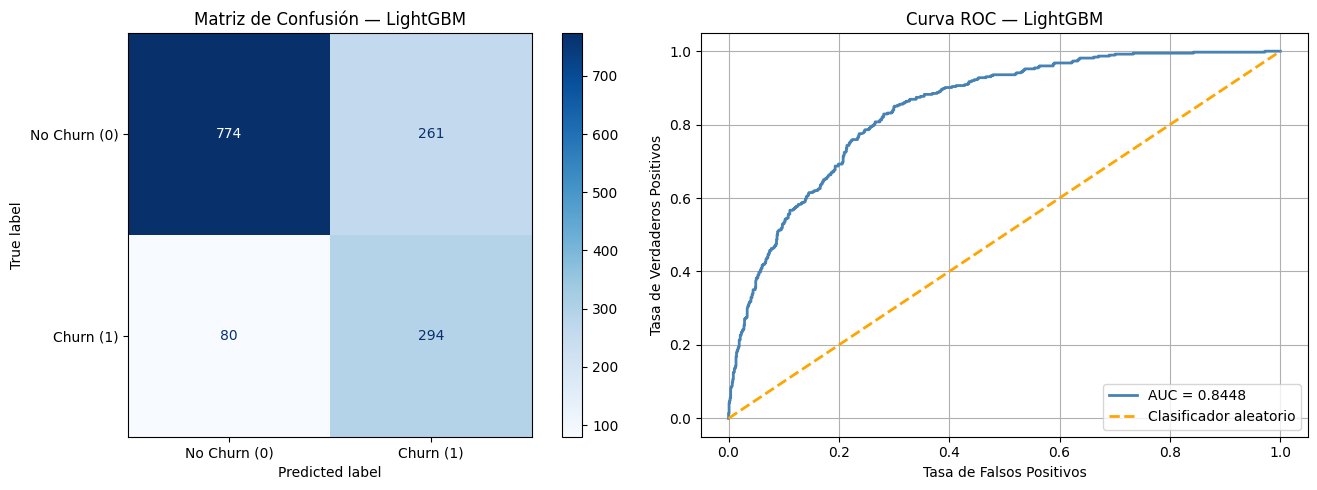

In [73]:
graficar_resultados(
    y_test,
    mejor_lgbm.predict(X_test),
    mejor_lgbm.predict_proba(X_test)[:, 1],
    "LightGBM"
)

A partir de la matriz de confusión, se observa que el modelo identificó correctamente 774 clientes que no deseaban abandonar el servicio y 294 clientes que sí presentaban intención de churn. Asimismo, se evidencian 80 falsos negativos, correspondientes a clientes con intención de abandono que no fueron detectados, y 261 falsos positivos, es decir, clientes clasificados como posibles abandonos cuando realmente no lo eran. Esto confirma nuevamente el patrón observado en modelos anteriores: una alta capacidad para detectar clientes con riesgo de abandono (recall alto), aunque sacrificando algo de precision.

Al observar la curva ROC, se evidencia un AUC = 0.8448, indicando una buena capacidad discriminativa del modelo para diferenciar entre clientes que desean abandonar el servicio y aquellos que no. La curva mantiene un comportamiento similar al de los modelos previamente evaluados, aproximándose relativamente rápido hacia la esquina superior izquierda.

En términos generales, se evidencia un patrón bastante consistente entre todos los modelos evaluados, sin diferencias sustanciales en las métricas obtenidas. Esto sugiere que el dataset podría tener un límite en la capacidad de separación entre clases, haciendo que distintos algoritmos converjan hacia desempeños muy similares, especialmente en métricas como ROC AUC, recall y F1-score.

### **2.5.5 Tabla comparativa general**

Dado que se analizó cada modelo individualmente, se procederá a consolidar los resultados en una tabla comparativa que refleja las métricas de evaluación y el tiempo de entrenamiento de cada uno, con el fin de identificar el modelo con mejor desempeño general.

In [68]:
resultados_finales = pd.concat([
    pd.DataFrame(resultados_rf).T,
    pd.DataFrame(resultados_xgb).T,
    pd.DataFrame(resultados_cat).T,
    pd.DataFrame(resultados_lgbm).T
]).drop(columns=["Modelo"])

resultados_finales

,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Mejores Hiperparámetros,Mejor ROC AUC CV,Tiempo (s),Iteraciones
Random Forest,0.77005,0.54902,0.748663,0.633484,0.841796,"{'model__bootstrap': True, 'model__criterion':...",0.846786,487.397619,648
XGBoost,0.7445,0.511945,0.802139,0.625,0.848224,"{'model__colsample_bytree': 0.8, 'model__gamma...",0.849952,169.388615,1152
CatBoost,0.7445,0.511986,0.799465,0.624217,0.846108,"{'model__depth': 4, 'model__iterations': 200, ...",0.850559,379.338475,288
LightGBM,0.757984,0.52973,0.786096,0.632939,0.844818,"{'model__colsample_bytree': 0.8, 'model__learn...",0.846724,653.675391,1152


Tras analizar los resultados de los cuatro modelos, se selecciona CatBoost como modelo final. Su ``ROC AUC CV`` de 0.8506 es el más alto del grupo, siendo esta la métrica más confiable al calcularse sobre 5 particiones distintas y no depender de un split específico. En el conjunto de prueba mantiene un ROC AUC de 0.8461 y un recall de 0.7995, prácticamente idéntico al de XGBoost (0.8021), una diferencia de apenas 0.003 que en términos prácticos es insignificante. Por estas razones, CatBoost ofrece la mejor capacidad discriminatoria general y es el modelo seleccionado para su posterior despliegue.

Por último, pasaremos el archivo a formato .joblib para seguir con la siguiente sección del miniproyecto.

In [78]:
joblib.dump(mejor_cat, "../app/model.joblib")

['../app/model.joblib']

# **Sección 3. Importancia de Características** 

Se cargan los cuatro modelos ya entrenados (`Random Forest`, `XGBoost`, `CatBoost`, `LightGBM`) junto con los conjuntos de datos de entrenamiento y prueba generados en el notebook anterior.

## **3.1 Instalación de dependencias y configuración**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from lime.lime_tabular import LimeTabularExplainer

# Configuración visual global
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11
})

SEED = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## **3.2 Carga de modelos y datos**

In [4]:
import sys
!{sys.executable} -m pip install catboost
!{sys.executable} -m pip install lightgbm
# Cargar los cuatro pipelines entrenados
rf_pipe   = joblib.load('../data/mejor_rf.joblib')
xgb_pipe  = joblib.load('../data/mejor_xgb.joblib')
cat_pipe  = joblib.load('../data/mejor_cat.joblib')
lgbm_pipe = joblib.load('../data/mejor_lgbm.joblib')

# Cargar conjuntos de entrenamiento y prueba
X_train = joblib.load('../data/X_train.joblib').reset_index(drop=True)
X_test  = joblib.load('../data/X_test.joblib').reset_index(drop=True)
y_train = np.array(joblib.load('../data/y_train.joblib'))
y_test  = np.array(joblib.load('../data/y_test.joblib'))

print(f'Entrenamiento : {X_train.shape[0]} filas | Prueba: {X_test.shape[0]} filas')
print(f'Variables     : {X_train.shape[1]} features originales')
print(f'Distribución churn (test) — No: {(y_test==0).sum()} | Sí: {(y_test==1).sum()}')

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ---------------------------- ----------- 1.0/1.5 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.3 MB/s  0:00:00
Entrenamiento : 5634 filas | Prueba: 1409 filas
Variables     : 19 features originales
Distribución churn (test) — No: 1035 | Sí: 374


In [ ]:
#Extraer el preprocesador y los nombres de features transformadas
preprocessor  = rf_pipe.named_steps['preprocessor']
feature_names = list(preprocessor.get_feature_names_out())

# Aplicar preprocesamiento (necesario para LIME)
X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f'Features tras preprocesamiento: {len(feature_names)}')
print('Ejemplo de nombres:', feature_names[:6], '...')

Features tras preprocesamiento: 46
Ejemplo de nombres: ['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'cat__gender_Female', 'cat__gender_Male', 'cat__SeniorCitizen_0'] ...


In [ ]:
modelos = {
    'Random Forest': rf_pipe,
    'XGBoost':       xgb_pipe,
    'CatBoost':      cat_pipe,
    'LightGBM':      lgbm_pipe
}

COLOR_MODELOS = {
    'Random Forest': '#2E86AB',
    'XGBoost':       '#2E86AB',
    'CatBoost':      '#2E86AB',
    'LightGBM':      '#2E86AB'
}

print('Modelos cargados:', list(modelos.keys()))

Modelos cargados: ['Random Forest', 'XGBoost', 'CatBoost', 'LightGBM']


La importancia de características cuantifica la contribución de cada variable al poder predictivo del modelo. Su interpretación varía según el algoritmo:

| Modelo | Tipo de importancia |
|---|---|
| **Random Forest** | Disminución media en impureza de Gini (MDI) |
| **XGBoost** | Ganancia promedio (gain) al usar la feature en un split |
| **CatBoost** | Score de predicción de pérdida (symmetric trees) |
| **LightGBM** | Número de veces que la feature se usa en splits (split count) |


**Nota metodológica**: Los modelos se entrenaron con pipelines que incluyen un `ColumnTransformer`. Las importancias se recuperan del estimador final (`named_steps['model']`) y se mapean a los nombres de features transformadas generados por `get_feature_names_out()`.

In [9]:
def extraer_top10_importancias(pipeline, feature_names, nombre_modelo):
    """
    pipeline      : Pipeline  — Pipeline con preprocesador y modelo.
    feature_names : list      — Nombres de las features post-preprocesamiento.
    nombre_modelo : str       — Etiqueta identificadora del modelo.
    """
    clf = pipeline.named_steps['model']
    importancias = clf.feature_importances_

    # Normalizar a [0,1] para comparación entre modelos
    importancias_norm = importancias / importancias.sum()

    # Seleccionar top 10
    top10_idx = np.argsort(importancias_norm)[::-1][:10]

    # Limpiar prefijos 'num__' y 'cat__'
    nombres_limpios = [
        feature_names[i].replace('num__', '').replace('cat__', '')
        for i in top10_idx
    ]

    return pd.DataFrame({
        'feature':     nombres_limpios,
        'importancia': importancias_norm[top10_idx],
        'modelo':      nombre_modelo
    })


# Extraer para los 4 modelos
dfs_importancias = {}
for nombre, pipeline in modelos.items():
    dfs_importancias[nombre] = extraer_top10_importancias(pipeline, feature_names, nombre)

## **3.3 Gráficas individuales de importancia por modelo**

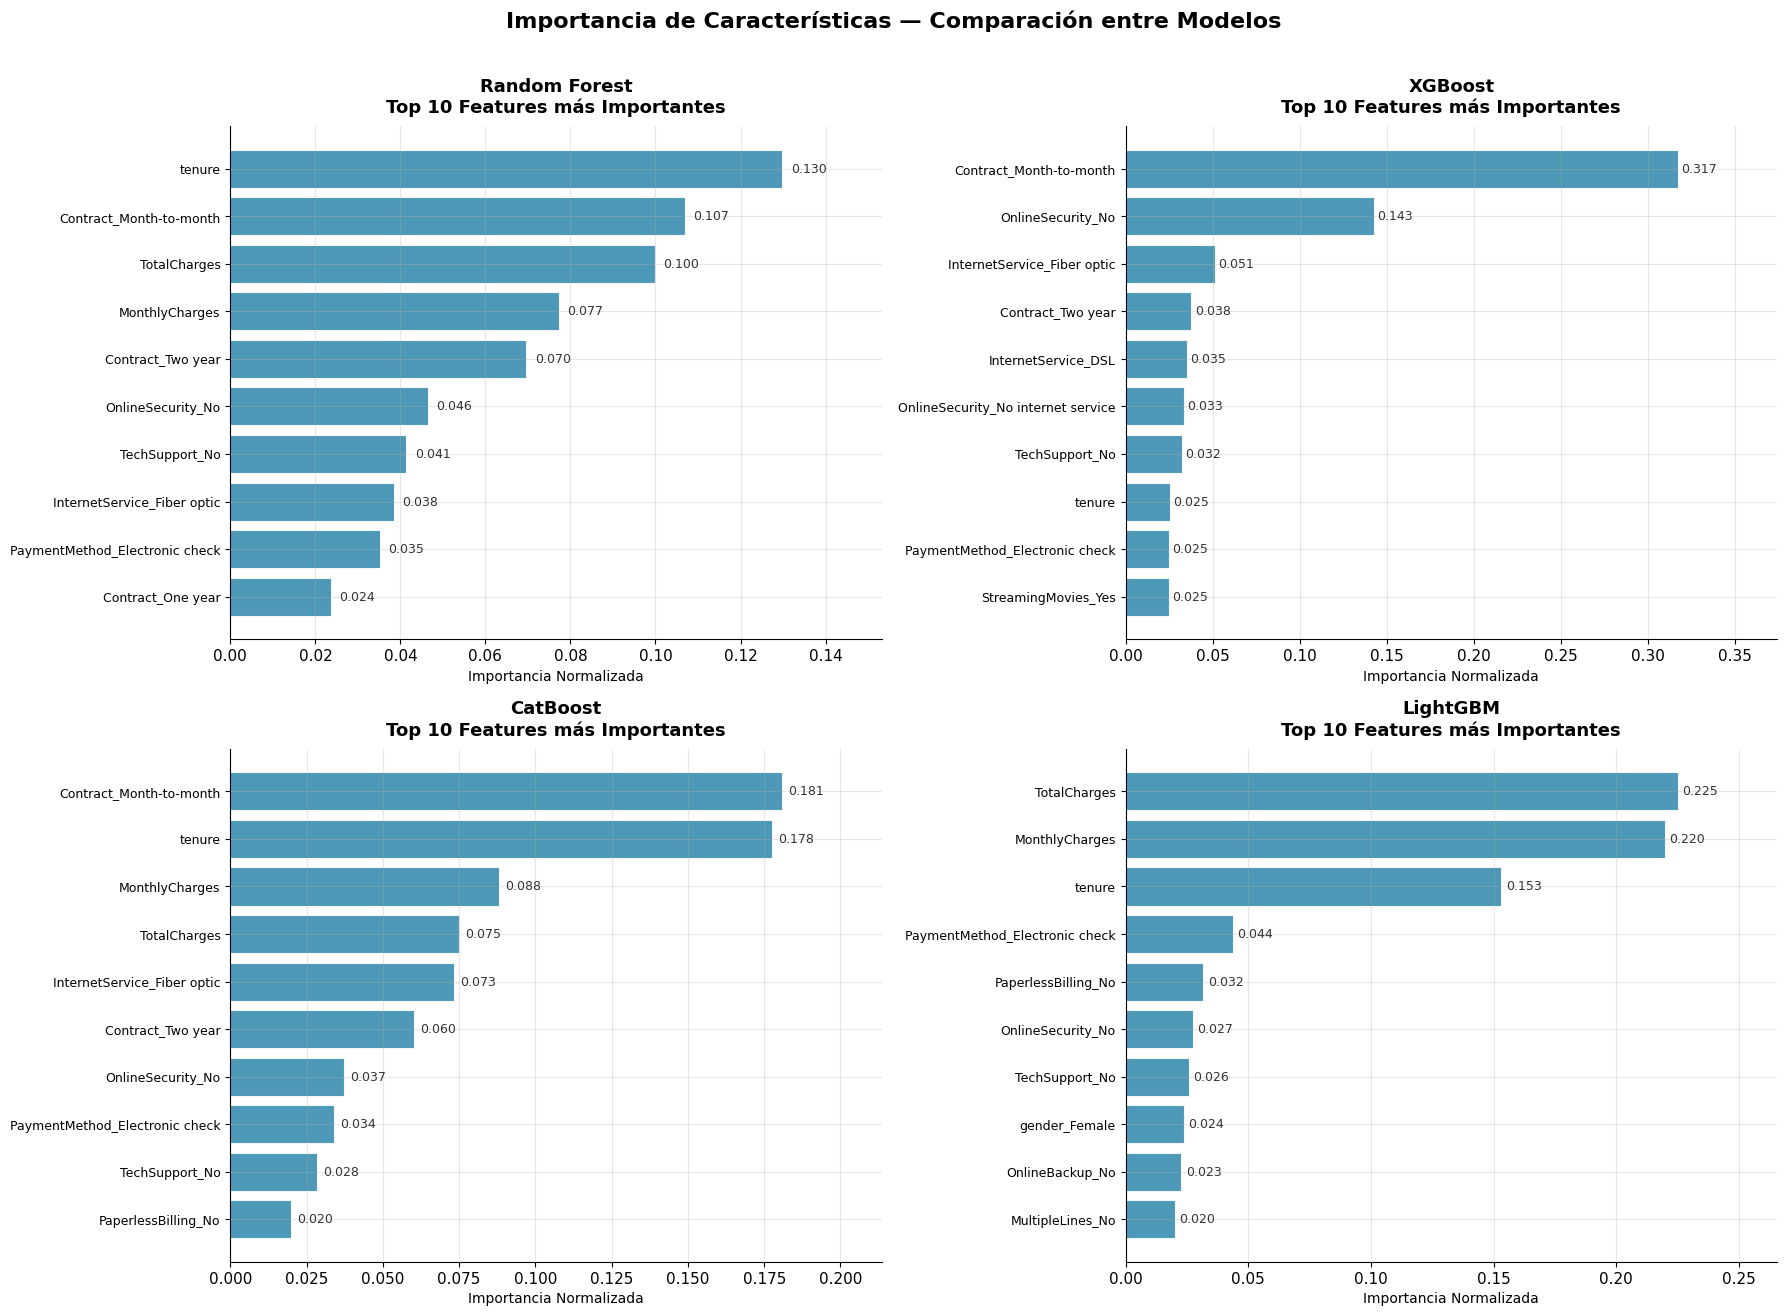

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
axes = axes.flatten()

for ax, (nombre, df) in zip(axes, dfs_importancias.items()):
    color    = COLOR_MODELOS[nombre]
    df_plot  = df.sort_values('importancia', ascending=True)

    bars = ax.barh(
        df_plot['feature'], df_plot['importancia'],
        color=color, alpha=0.85, edgecolor='white', linewidth=0.8
    )

    for bar, val in zip(bars, df_plot['importancia']):
        ax.text(
            bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9, color='#333333'
        )

    ax.set_title(f'{nombre}\nTop 10 Features más Importantes',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Importancia Normalizada', fontsize=10)
    ax.set_xlim(0, df_plot['importancia'].max() * 1.18)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Importancia de Características — Comparación entre Modelos',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/fig_importancia_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

Los cuatro modelos coinciden bastante en cuáles variables son las más importantes para predecir el churn. La que más se repite es **`tenure`**, prácticamente en todos aparece dentro de las primeras posiciones. En general, los clientes que llevan poco tiempo con la empresa tienen mucha más probabilidad de irse, mientras que los que ya tienen varios meses o años suelen quedarse.

Otra variable que pesa bastante es **`Contract_Month-to-month`**. Esto también tiene lógica porque un contrato mensual no genera mucho compromiso con la empresa, entonces el cliente puede cancelar el servicio en cualquier momento sin tantas consecuencias.

También resaltan **`MonthlyCharges`** y **`TotalCharges`**, especialmente en LightGBM. Parece que cuando un cliente nuevo paga cargos altos desde el inicio, la percepción costo-beneficio no siempre es buena y eso termina aumentando el riesgo de abandono.

En varios modelos también aparecen **`OnlineSecurity_No`** y **`TechSupport_No`**. Básicamente, los clientes que no tienen servicios adicionales o soporte técnico parecen tener menos “dependencia” del proveedor, entonces cambiarse resulta más fácil.

Con **`InternetService_Fiber optic`** pasa algo curioso. Aunque es un servicio mejor en teoría, los clientes de fibra muestran más churn. Probablemente porque son planes más caros o porque en ese segmento hay más competencia y más opciones para cambiarse.

Por último, **`PaymentMethod_Electronic check`** también sale repetidamente como una variable importante. No necesariamente significa que el método de pago cause el churn, pero sí parece estar relacionado con perfiles de clientes que abandonan más el servicio.

En general, el churn está mucho más relacionado con la antigüedad del cliente y el tipo de contrato que con variables aisladas. Los resultados sugieren que estrategias como ofrecer contratos más largos, agregar servicios adicionales o mejorar la experiencia de los clientes nuevos podrían ayudar bastante a reducir el abandono.


## **3.4 Mapa de calor comparativo**

A continuación se muestran las features del top 10 comunes entre modelos.

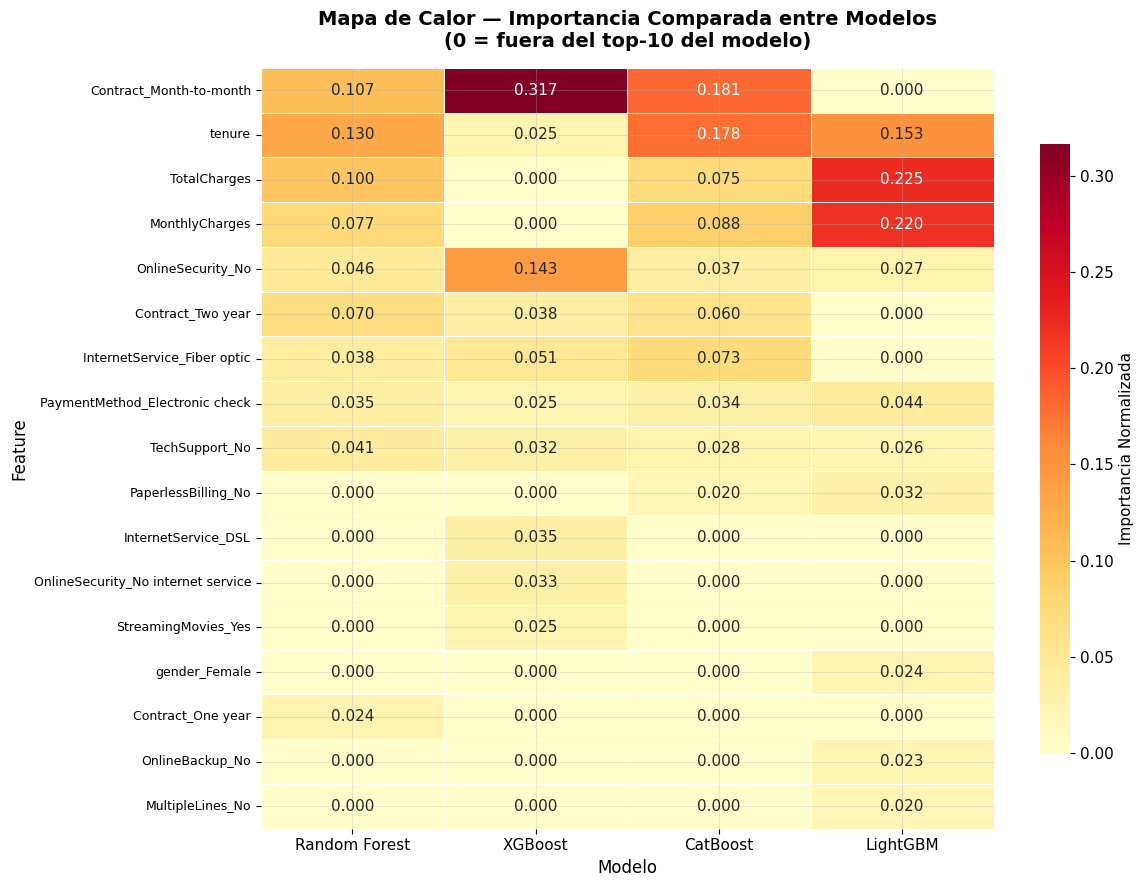

In [ ]:

features_union = sorted(set(
    feat for df in dfs_importancias.values() for feat in df['feature']
))

matriz = pd.DataFrame(index=features_union, columns=list(modelos.keys()), dtype=float)
for nombre, df in dfs_importancias.items():
    for _, row in df.iterrows():
        matriz.loc[row['feature'], nombre] = row['importancia']
matriz = matriz.fillna(0)

# descendente
matriz['media'] = matriz.mean(axis=1)
matriz = matriz.sort_values('media', ascending=False).drop(columns='media')

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    matriz, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={'label': 'Importancia Normalizada', 'shrink': 0.8}
)
ax.set_title('Mapa de Calor — Importancia Comparada entre Modelos\n'
             '(0 = fuera del top-10 del modelo)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('../data/fig_heatmap_importancias.png', dpi=150, bbox_inches='tight')
plt.show()

El heatmap deja ver que hay variables en las que casi todos los modelos “se ponen de acuerdo” y otras donde ya depende más de cómo cada algoritmo interpreta los datos.

Primero está el grupo de mayor consenso, o sea las variables que aparecen como importantes en los 4 modelos: **`tenure`**, **`OnlineSecurity_No`**, **`PaymentMethod_Electronic check`** y **`TechSupport_No`**. Básicamente son las variables más sólidas del análisis porque sin importar el algoritmo siempre terminan teniendo peso en la predicción del churn.

Después está el consenso parcial, donde las variables aparecen en 2 o 3 modelos pero no en todos. Ahí entran **`Contract_Month-to-month`**, **`TotalCharges`**, **`MonthlyCharges`**, **`Contract_Two year`**, **`InternetService_Fiber optic`** y **`PaperlessBilling_No`**. En estos casos la importancia cambia dependiendo de cómo cada modelo maneja relaciones entre variables o problemas de colinealidad.

También hay variables que prácticamente son específicas de un solo modelo. Por ejemplo **`gender_Female`** solo aparece en LightGBM. Eso no necesariamente significa que sea súper importante, más bien parece que LightGBM logra captar patrones pequeños o muy sutiles que para los otros modelos son irrelevantes o simplemente ruido.

En general, el análisis sugiere que se podría construir un modelo más simple usando solo las variables de consenso total y aun así mantener un rendimiento bastante bueno, además sería mucho más interpretable. Igual valdría la pena incluir **`Contract_Month-to-month`**, porque aunque no aparece en todos los modelos, en XGBoost tuvo la importancia más alta de todas (0.317), entonces claramente aporta bastante información para detectar churn.

# **Sección 4. Interpretabilidad Local con LIME**

LIME se utiliza para entender por qué el modelo tomó una decisión en una observación. A diferencia de la importancia global de variables, aquí el enfoque es local, es decir, explicar un solo caso a la vez.

El procedimiento funciona más o menos así:

1. Primero toma una instancia específica (x) y genera variaciones pequeñas alrededor de ella, como si “alterara” ligeramente los valores originales.
2. Luego esas nuevas muestras se pasan al modelo ya entrenado para ver cómo cambian las predicciones.
3. Finalmente, LIME ajusta un modelo lineal simple sobre esa vecindad, dándole más peso a las muestras más cercanas al punto original. Los coeficientes de ese modelo permiten interpretar qué variables están empujando la predicción hacia churn o hacia no churn.

Algo importante es que LIME trabaja con los datos ya preprocesados (`X_train_proc` y `X_test_proc`). Esto se hace porque el modelo realmente “ve” los datos transformados y no los datos originales en bruto. Entonces, si LIME usara variables sin procesar, las perturbaciones no serían coherentes con el comportamiento real del modelo.

### **Selección de casos representativos**

Para el análisis se eligieron tres instancias del conjunto de prueba con perfiles diferentes para observar cómo cambia la explicación dependiendo del tipo de cliente y entender qué variables influyen más en cada caso.

In [ ]:
proba_test = rf_pipe.predict_proba(X_test)[:, 1]

# verdadero positivo
idx_alto  = np.where((proba_test > 0.85) & (y_test == 1))[0][0]

# verdadero negativo
idx_bajo  = np.where((proba_test < 0.10) & (y_test == 0))[0][0]

# incertidumbre (probabilidad ~0.5)
idx_medio = np.where((proba_test > 0.45) & (proba_test < 0.55))[0][0]

casos = {
    'Caso 1 — Alto Riesgo':   idx_alto,
    'Caso 2 — Bajo Riesgo':   idx_bajo,
    'Caso 3 — Zona Incierta': idx_medio
}


resumen = []
for nombre, idx in casos.items():
    resumen.append({
        'Caso':              nombre,
        'Índice':            idx,
        'P(Churn)':          f'{proba_test[idx]:.3f}',
        'Etiqueta Real':     'Churn' if y_test[idx] == 1 else 'No Churn',
        'Predicción Modelo': 'Churn' if proba_test[idx] > 0.5 else 'No Churn',
        'tenure':            X_test.iloc[idx]['tenure'],
        'Contract':          X_test.iloc[idx]['Contract'],
        'MonthlyCharges':    X_test.iloc[idx]['MonthlyCharges'],
        'InternetService':   X_test.iloc[idx]['InternetService']
    })


display(pd.DataFrame(resumen).set_index('Caso'))

,Índice,P(Churn),Etiqueta Real,Predicción Modelo,tenure,Contract,MonthlyCharges,InternetService
Caso,,,,,,,,
Caso 1 — Alto Riesgo,29,0.869,Churn,Churn,3,Month-to-month,89.45,Fiber optic
Caso 2 — Bajo Riesgo,0,0.022,No Churn,No Churn,72,Two year,114.05,Fiber optic
Caso 3 — Zona Incierta,3,0.498,No Churn,No Churn,18,Month-to-month,78.20,Fiber optic


In [14]:
explainer = LimeTabularExplainer(
    training_data=X_train_proc,
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    discretize_continuous=True,   # Discretiza numéricas para mayor interpretabilidad
    random_state=SEED
)

# Función de predicción: accede al clasificador dentro del pipeline
clf_rf = rf_pipe.named_steps['model']

def predict_fn(x_proc):
    """Wrapper para que LIME acceda al clasificador sin el preprocesador."""
    return clf_rf.predict_proba(x_proc)

print('LimeTabularExplainer configurado.')
print(f'Features de entrenamiento : {X_train_proc.shape[1]}')
print(f'Muestras de referencia    : {X_train_proc.shape[0]}')

LimeTabularExplainer configurado.
Features de entrenamiento : 46
Muestras de referencia    : 5634


## **4.1 (Caso 1) Cliente con Alto Riesgo de Churn (Verdadero Positivo)**

In [23]:
print('CASO 1 — PERFIL DEL CLIENTE')
print(X_test.iloc[idx_alto].to_string())
print(f'\nP(Churn) = {proba_test[idx_alto]:.3f} | Etiqueta real: {"Churn" if y_test[idx_alto]==1 else "No Churn"}')

CASO 1 — PERFIL DEL CLIENTE
gender                        Female
SeniorCitizen                      0
Partner                           No
Dependents                        No
tenure                             3
PhoneService                     Yes
MultipleLines                     No
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                      Yes
StreamingMovies                  Yes
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                 89.45
TotalCharges                  240.45

P(Churn) = 0.869 | Etiqueta real: Churn


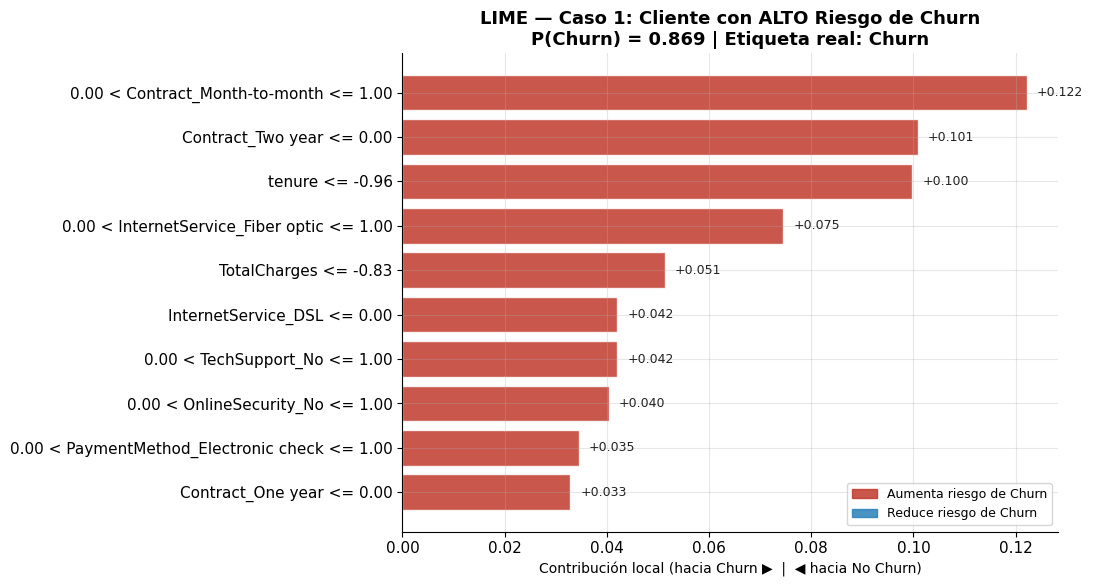

In [24]:
exp_alto = explainer.explain_instance(
    data_row=X_test_proc[idx_alto],
    predict_fn=predict_fn,
    num_features=10,
    num_samples=5000
)

features_alto = exp_alto.as_list()
labels_alto   = [f[0].replace('num__', '').replace('cat__', '') for f in features_alto]
valores_alto  = [f[1] for f in features_alto]
colores_alto  = ['#C0392B' if v > 0 else '#2980B9' for v in valores_alto]

orden = np.argsort(np.abs(valores_alto))
labels_ord  = [labels_alto[i]  for i in orden]
valores_ord = [valores_alto[i] for i in orden]
colores_ord = [colores_alto[i] for i in orden]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(labels_ord, valores_ord, color=colores_ord, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, valores_ord):
    offset = 0.002 if val >= 0 else -0.002
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', fontsize=9, color='#222222',
            ha='left' if val >= 0 else 'right')

ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
ax.set_title(
    f'LIME — Caso 1: Cliente con ALTO Riesgo de Churn\n'
    f'P(Churn) = {proba_test[idx_alto]:.3f} | Etiqueta real: Churn',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Contribución local (hacia Churn ▶  |  ◀ hacia No Churn)', fontsize=10)
ax.legend(handles=[
    mpatches.Patch(color='#C0392B', alpha=0.85, label='Aumenta riesgo de Churn'),
    mpatches.Patch(color='#2980B9', alpha=0.85, label='Reduce riesgo de Churn')
], loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../data/fig_lime_caso1_alto.png', dpi=150, bbox_inches='tight')
plt.show()

Este cliente fue clasificado correctamente como churn, con una probabilidad cercana al **87%**. Al mirar la explicación de LIME se entiende bastante bien por qué el modelo tomó esa decisión.

El factor que más empuja la predicción es **`Contract_Month-to-month = 1`**, el cliente tiene un contrato mensual, así que no existe mucho compromiso con la empresa y puede cancelar el servicio en cualquier momento sin penalización. También influye bastante que el **`tenure`** sea muy bajo, apenas unos 3 meses, el cliente todavía está “probando” el servicio y cualquier mala experiencia puede hacer que abandone rápido. Otro punto importante es la combinación entre **`InternetService_Fiber optic = 1`** y **`OnlineSecurity_No = 1`**, pues el cliente está pagando por un servicio premium como fibra óptica, pero sin servicios adicionales que aumenten la percepción de valor o generen más dependencia con la compañía. Además aparece **`PaymentMethod_Electronic check = 1`**, que ya venía mostrando una relación fuerte con churn en el análisis global. No significa necesariamente que el método de pago cause el abandono, pero sí parece estar asociado a clientes menos estables o menos fidelizados.

En general, este perfil sería un candidato claro para estrategias de retención temprana, tendría sentido ofrecerle un contrato anual con algún descuento, incluir seguridad online sin costo adicional o revisar si el precio del plan de fibra resulta competitivo para alguien que apenas está comenzando con el servicio.


## **4.2 (Caso 2) Cliente con Bajo Riesgo de Churn (Verdadero Negativo)**

In [18]:
print('CASO 2 — PERFIL DEL CLIENTE')
print(X_test.iloc[idx_bajo].to_string())
print(f'\nP(Churn) = {proba_test[idx_bajo]:.3f} | Etiqueta real: {"Churn" if y_test[idx_bajo]==1 else "No Churn"}')

CASO 2 — PERFIL DEL CLIENTE
gender                                 Male
SeniorCitizen                             0
Partner                                 Yes
Dependents                              Yes
tenure                                   72
PhoneService                            Yes
MultipleLines                           Yes
InternetService                 Fiber optic
OnlineSecurity                          Yes
OnlineBackup                            Yes
DeviceProtection                        Yes
TechSupport                             Yes
StreamingTV                             Yes
StreamingMovies                         Yes
Contract                           Two year
PaperlessBilling                        Yes
PaymentMethod       Credit card (automatic)
MonthlyCharges                       114.05
TotalCharges                         8468.2

P(Churn) = 0.022 | Etiqueta real: No Churn


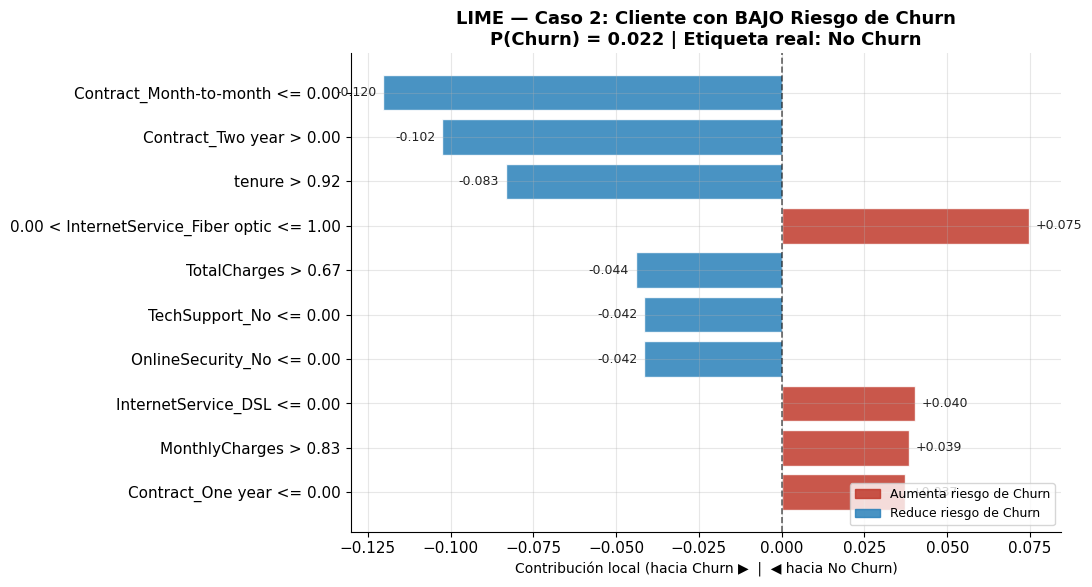

In [19]:
exp_bajo = explainer.explain_instance(
    data_row=X_test_proc[idx_bajo],
    predict_fn=predict_fn,
    num_features=10,
    num_samples=5000
)

features_bajo = exp_bajo.as_list()
labels_bajo   = [f[0].replace('num__', '').replace('cat__', '') for f in features_bajo]
valores_bajo  = [f[1] for f in features_bajo]
colores_bajo  = ['#C0392B' if v > 0 else '#2980B9' for v in valores_bajo]

orden = np.argsort(np.abs(valores_bajo))
labels_ord  = [labels_bajo[i]  for i in orden]
valores_ord = [valores_bajo[i] for i in orden]
colores_ord = [colores_bajo[i] for i in orden]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(labels_ord, valores_ord, color=colores_ord, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, valores_ord):
    offset = 0.002 if val >= 0 else -0.002
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', fontsize=9, color='#222222',
            ha='left' if val >= 0 else 'right')

ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
ax.set_title(
    f'LIME — Caso 2: Cliente con BAJO Riesgo de Churn\n'
    f'P(Churn) = {proba_test[idx_bajo]:.3f} | Etiqueta real: No Churn',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Contribución local (hacia Churn ▶  |  ◀ hacia No Churn)', fontsize=10)
ax.legend(handles=[
    mpatches.Patch(color='#C0392B', alpha=0.85, label='Aumenta riesgo de Churn'),
    mpatches.Patch(color='#2980B9', alpha=0.85, label='Reduce riesgo de Churn')
], loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../data/fig_lime_caso2_bajo.png', dpi=150, bbox_inches='tight')
plt.show()

Este cliente fue clasificado correctamente como **no churn**, con una probabilidad de abandono bastante baja, alrededor del **2.2%**. La explicación de LIME deja claro que el modelo lo ve como un cliente muy estable y difícil de perder.

Lo que más ayuda a reducir el riesgo son las variables asociadas a fidelización. La principal es **`tenure > 65 meses`**, llevar aproximadamente 6 años con la empresa es una señal fuerte de permanencia, porque el cliente ya pasó por muchas oportunidades donde pudo cancelar y aun así siguió usando el servicio. También influye bastante tener **`Contract_Two year = 1`**. Un contrato de dos años suele reflejar más compromiso y hace menos probable que el cliente se vaya de manera repentina. Además, aparecen variables como **`OnlineSecurity_Yes`**, **`TechSupport_Yes`** y **`DeviceProtection_Yes`**. Tener varios servicios adicionales hace que el cliente dependa más del proveedor y perciba más valor en el paquete completo, entonces cambiarse no es tan sencillo. Otro detalle importante es el método de pago: **`PaymentMethod_Credit card (automatic)`**, está asociado con clientes más organizados o acostumbrados al servicio, porque ya lo integraron a su rutina mensual.

Por el lado del riesgo, sí hay algunas variables que aumentan un poco la probabilidad de churn, aunque no son suficientes para cambiar la predicción. Por ejemplo, los **`MonthlyCharges`** altos y el servicio de **fibra óptica** podrían generar cierta presión por precio, especialmente si existen opciones más baratas en el mercado, de todas formas el resto del perfil compensa ese posible riesgo.

En general, este es prácticamente el perfil de cliente que cualquier empresa quisiera conservar, no parece necesitar estrategias urgentes de retención y más bien sirve como referencia de lo que funciona bien: contratos largos, servicios adicionales y métodos de pago automatizados.


## **4.3 (Caso 3) Cliente en Zona de Incertidumbre (Probabilidad ≈ 0.5)**

In [20]:
print('CASO 3 — PERFIL DEL CLIENTE')
print(X_test.iloc[idx_medio].to_string())
print(f'\nP(Churn) = {proba_test[idx_medio]:.3f} | Etiqueta real: {"Churn" if y_test[idx_medio]==1 else "No Churn"}')

CASO 3 — PERFIL DEL CLIENTE
gender                          Male
SeniorCitizen                      0
Partner                          Yes
Dependents                        No
tenure                            18
PhoneService                     Yes
MultipleLines                     No
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                 Yes
TechSupport                      Yes
StreamingTV                       No
StreamingMovies                   No
Contract              Month-to-month
PaperlessBilling                  No
PaymentMethod       Electronic check
MonthlyCharges                  78.2
TotalCharges                 1468.75

P(Churn) = 0.498 | Etiqueta real: No Churn


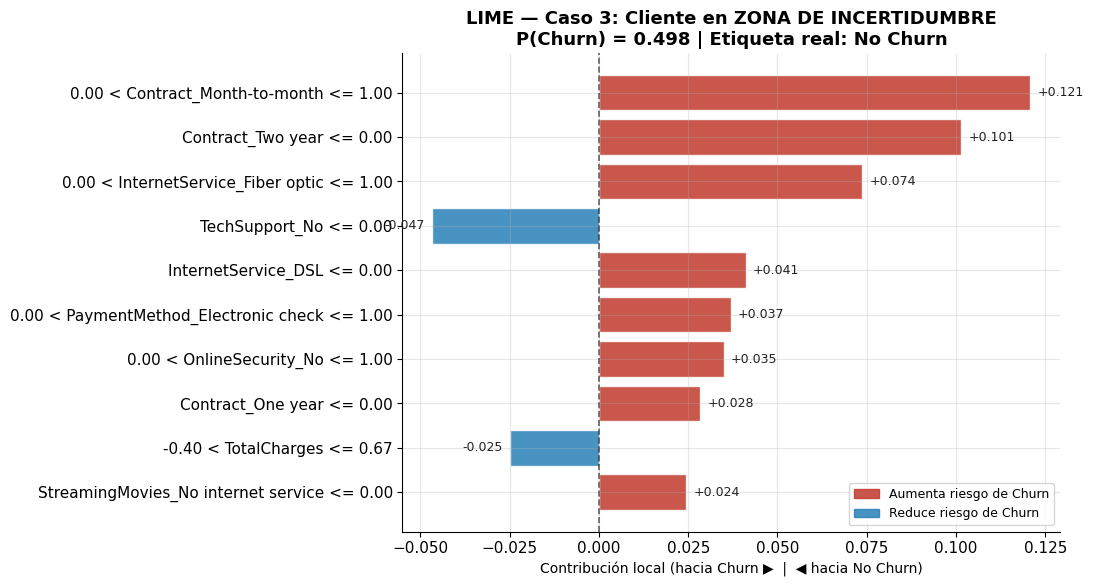

In [21]:
exp_medio = explainer.explain_instance(
    data_row=X_test_proc[idx_medio],
    predict_fn=predict_fn,
    num_features=10,
    num_samples=5000
)

features_medio = exp_medio.as_list()
labels_medio   = [f[0].replace('num__', '').replace('cat__', '') for f in features_medio]
valores_medio  = [f[1] for f in features_medio]
colores_medio  = ['#C0392B' if v > 0 else '#2980B9' for v in valores_medio]

orden = np.argsort(np.abs(valores_medio))
labels_ord  = [labels_medio[i]  for i in orden]
valores_ord = [valores_medio[i] for i in orden]
colores_ord = [colores_medio[i] for i in orden]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(labels_ord, valores_ord, color=colores_ord, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, valores_ord):
    offset = 0.002 if val >= 0 else -0.002
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', fontsize=9, color='#222222',
            ha='left' if val >= 0 else 'right')

ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
ax.set_title(
    f'LIME — Caso 3: Cliente en ZONA DE INCERTIDUMBRE\n'
    f'P(Churn) = {proba_test[idx_medio]:.3f} | Etiqueta real: {"Churn" if y_test[idx_medio]==1 else "No Churn"}',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Contribución local (hacia Churn ▶  |  ◀ hacia No Churn)', fontsize=10)
ax.legend(handles=[
    mpatches.Patch(color='#C0392B', alpha=0.85, label='Aumenta riesgo de Churn'),
    mpatches.Patch(color='#2980B9', alpha=0.85, label='Reduce riesgo de Churn')
], loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../data/fig_lime_caso3_medio.png', dpi=150, bbox_inches='tight')
plt.show()

El modelo le asigna aproximadamente un **49.8% de probabilidad de churn**, o sea prácticamente está en el límite entre clasificarlo como churn o no churn. Al final la etiqueta real es **No Churn**, así que el modelo estuvo muy cerca de cometer un falso positivo. LIME muestra que esto pasa porque el cliente tiene señales mezcladas: algunas variables apuntan claramente a riesgo de abandono, mientras que otras indican estabilidad, entonces el modelo termina “dividido”.

Entre los factores que aumentan el riesgo aparecen otra vez **`Contract_Month-to-month = 1`**, que sigue siendo uno de los patrones más fuertes asociados al churn, también influyen **`OnlineSecurity_No = 1`** y **`OnlineBackup_No = 1`**, porque el cliente no tiene servicios adicionales de seguridad o respaldo, algo que ya se había visto repetidamente en perfiles de mayor riesgo. A eso se suma **`PaymentMethod_Electronic check = 1`**, que vuelve a aparecer como una señal relacionada con churn. Y aunque el cliente tiene alrededor de **18 meses de antigüedad**, eso lo deja en una especie de zona intermedia: ya no es un cliente nuevo, pero tampoco tiene la estabilidad de alguien que lleva muchos años con la compañía. 

Por otro lado, también hay variables que ayudan a reducir el riesgo. Por ejemplo **`TechSupport_Yes = 1`** y **`DeviceProtection_Yes = 1`** indican que el cliente sí utiliza algunos servicios adicionales, lo que genera más dependencia con la empresa y hace menos probable que se vaya. Además, **`Partner_Yes = 1`** suele relacionarse con perfiles más estables y menor tendencia al abandono. Incluso **`PaperlessBilling_No = 0`** termina ayudando un poco en este caso, porque dentro de este segmento el modelo asocia la facturación tradicional con clientes menos propensos al churn.

Este tipo de casos son probablemente los más útiles para analizar con LIME, porque muestran clientes “grises”, donde el modelo no está completamente seguro. Para un equipo de retención, no sería necesario hacer una intervención agresiva; algo relativamente simple, como ofrecer un descuento o incentivar el cambio a un contrato anual, probablemente sería suficiente para mover a este cliente hacia un perfil de bajo riesgo.


## **4.4 Resumen comparativo**

| Factor | Caso 1 (Alto riesgo) | Caso 2 (Bajo riesgo) | Caso 3 (Incierto) |
|---|:---:|:---:|:---:|
| Contrato mensual | ↑ Riesgo | — | ↑ Riesgo |
| Contrato 2 años | — | ↓ Riesgo | — |
| Tenure bajo | ↑ Riesgo | — | — |
| Tenure alto | — | ↓ Riesgo | — |
| Sin seguridad online | ↑ Riesgo | — | ↑ Riesgo |
| Con soporte técnico | — | ↓ Riesgo | ↓ Riesgo |
| Pago cheque electrónico | ↑ Riesgo | — | ↑ Riesgo |
| Pago tarjeta automático | — | ↓ Riesgo | — |

**Conclusiones clave**:

1. El factor que más se repite en los casos con mayor riesgo es el **tipo de contrato**. Los clientes con contratos mes a mes casi siempre terminan teniendo probabilidades de churn más altas, incluso cuando otras variables son relativamente favorables.

2. La **antigüedad del cliente (`tenure`)** funciona como una especie de “protección”. Mientras más tiempo lleva una persona con la empresa, más difícil es que variables negativas terminen empujando completamente la predicción hacia churn.

3. Los **servicios adicionales** como `TechSupport`, `OnlineSecurity` o `DeviceProtection` ayudan bastante a reducir el riesgo, cuando un cliente tiene varios de estos servicios al mismo tiempo, el modelo suele interpretarlo como una relación más fuerte con la empresa y la ausencia conjunta de varios sí aparece muy asociada al abandono.

4. Los clientes que quedan en la llamada **zona de incertidumbre** son probablemente los más interesantes desde el punto de vista de negocio, son perfiles que tienen varios de los mismos factores de riesgo que los clientes churn, pero al mismo tiempo cuentan con algunos elementos que compensan parcialmente ese riesgo, como más antigüedad o ciertos servicios activos, por eso parecen ser los más sensibles a estrategias de retención pequeñas o moderadas.



# **5. Diseño del sistema de despliegue MLOps**

La etapa final del proyecto consistió en transformar el modelo seleccionado en un servicio de inferencia funcional, de manera que pudiera recibir datos nuevos de clientes y devolver una predicción de abandono. Esta fase corresponde al componente MLOps del proyecto, porque conecta el trabajo de modelado con una estructura básica de operación, prueba, despliegue y monitoreo.

En el desarrollo previo se entrenaron y compararon cuatro modelos basados en árboles: **Random Forest, XGBoost, CatBoost y LightGBM**. El modelo seleccionado fue **CatBoost**, ya que obtuvo el mejor desempeño promedio en validación cruzada según la métrica principal definida, **ROC AUC**, con un valor aproximado de **0.8506**. Este modelo fue guardado como archivo serializado en `app/model.joblib`, para ser utilizado posteriormente por la API de inferencia.

## **5.1 Componentes implementados**

La arquitectura MLOps construida para el proyecto quedó conformada por los siguientes elementos:

| Componente | Archivo / carpeta | Función dentro del sistema |
|---|---|---|
| Modelo final | `app/model.joblib` | Contiene el pipeline entrenado con preprocesamiento y modelo CatBoost. |
| API de inferencia | `app/api.py` | Expone los endpoints para consultar el estado del servicio y generar predicciones. |
| Esquemas de validación | `app/schemas.py` | Define la estructura de entrada y salida usando Pydantic. |
| Pruebas unitarias | `tests/` | Verifican que la API y el modelo funcionen correctamente. |
| Contenedor Docker | `Dockerfile` | Empaqueta la API, el modelo y las dependencias en una imagen reproducible. |
| Dependencias | `requirements.txt` | Lista las librerías necesarias para ejecutar el proyecto. |
| CI/CD | `.github/workflows/ci.yml` | Automatiza pruebas, linting, construcción de imagen Docker y verificación del endpoint `/health`. |
| Documentación | `README.md` | Explica el proyecto, instalación, uso de la API, Docker, CI/CD y monitoreo. |

## **5.2 Servicio de inferencia con FastAPI**

El modelo final se expuso mediante una API construida con **FastAPI**. Esta API recibe los datos de un cliente en formato JSON, los convierte en un `DataFrame` con las mismas variables usadas durante el entrenamiento y los envía al pipeline guardado. Como el modelo serializado ya incluye el preprocesamiento, no se realiza codificación manual dentro de la API.

La API recibe las 19 variables predictoras originales del dataset, excluyendo `customerID` y `Churn`:

- `gender`
- `SeniorCitizen`
- `Partner`
- `Dependents`
- `tenure`
- `PhoneService`
- `MultipleLines`
- `InternetService`
- `OnlineSecurity`
- `OnlineBackup`
- `DeviceProtection`
- `TechSupport`
- `StreamingTV`
- `StreamingMovies`
- `Contract`
- `PaperlessBilling`
- `PaymentMethod`
- `MonthlyCharges`
- `TotalCharges`

La respuesta del endpoint de predicción incluye:

- `churn_probability`: probabilidad estimada de abandono.
- `prediction`: clasificación final, `Yes` si el cliente probablemente abandona y `No` en caso contrario.
- `threshold`: umbral de decisión utilizado, definido en 0.5.
- `model_name`: nombre del modelo usado para la inferencia.

## **5.3 Endpoints disponibles**

La API implementada cuenta con tres rutas principales:

| Endpoint | Método | Propósito |
|---|---|---|
| `/` | GET | Devuelve información general del servicio. |
| `/health` | GET | Verifica que la API esté activa y que el modelo haya sido cargado correctamente. |
| `/predict` | POST | Recibe los datos de un cliente y devuelve la predicción de churn. |

El endpoint más importante es `/predict`, porque es el que permite consumir el modelo entrenado desde una aplicación externa, un sistema empresarial o una interfaz de usuario.

## **5.4 Ejecución local con Uvicorn**

Durante el desarrollo, la API puede ejecutarse directamente en el entorno local usando **Uvicorn**, que es el servidor encargado de levantar la aplicación FastAPI.

```bash
uvicorn app.api:app --reload --port 8000
```

Una vez ejecutado el comando, la documentación interactiva queda disponible en:

```text
http://localhost:8000/docs
```

Desde esa interfaz se puede probar el endpoint `POST /predict` sin necesidad de construir una aplicación adicional. Esto permitió validar que la API recibía correctamente los datos del cliente y devolvía la probabilidad de churn junto con la predicción final.

Es importante distinguir que **Uvicorn ejecuta la API directamente en el entorno local**, usando las dependencias instaladas en el computador. Por eso es útil durante el desarrollo y las pruebas iniciales.

## **5.5 Contenerización con Docker**

Después de validar la API localmente, se construyó una imagen Docker para empaquetar el servicio completo. Docker permite que la API, el modelo y las dependencias se ejecuten dentro de un contenedor aislado, evitando problemas de compatibilidad entre computadores o entornos.

Los comandos utilizados para construir y ejecutar el contenedor fueron:

```bash
docker build -t telco-churn-api .
docker run -p 8000:8000 telco-churn-api
```

Aunque al ejecutar la API con Uvicorn y con Docker se visualiza la misma interfaz de FastAPI, la diferencia es que:

- Con **Uvicorn**, la API corre directamente en el entorno local.
- Con **Docker**, la API corre dentro de un contenedor con su propia instalación de Python, dependencias y archivos del proyecto.

Esto hace que Docker sea más adecuado para despliegues reproducibles, porque permite ejecutar el servicio en distintos equipos o servidores sin depender de la configuración local del usuario.

La ejecución en Docker fue validada correctamente, ya que el contenedor inició el servidor y permitió acceder a la documentación en:

```text
http://localhost:8000/docs
```

Además, el endpoint `/health` respondió correctamente, confirmando que el modelo fue cargado dentro del contenedor.

## **5.6 Pruebas unitarias**

Se incluyeron pruebas unitarias para validar el funcionamiento básico del sistema. Las pruebas verifican que:

- El archivo del modelo exista.
- El modelo pueda cargarse con `joblib`.
- El modelo tenga métodos de predicción.
- El endpoint `/health` responda correctamente.
- El endpoint `/predict` devuelva una respuesta válida.
- La probabilidad de churn se encuentre entre 0 y 1.
- La predicción final pertenezca a las clases esperadas: `Yes` o `No`.

Las pruebas pueden ejecutarse localmente con:

```bash
python -m pytest tests/ -v
```

Estas pruebas son importantes porque permiten detectar errores antes de subir cambios al repositorio o antes de construir una nueva imagen Docker.

## **5.7 Flujo CI/CD con GitHub Actions**

El proyecto incluye un flujo de trabajo de integración continua y despliegue básico mediante GitHub Actions, definido en:

```text
.github/workflows/ci.yml
```

Este flujo se ejecuta automáticamente cuando se realiza un `push` o un `pull request` en el repositorio. El pipeline está dividido en dos trabajos principales:

1. **Linting y pruebas unitarias**
   - Clona el repositorio.
   - Configura Python 3.10.
   - Instala las dependencias del proyecto.
   - Ejecuta `flake8` para verificar calidad de código.
   - Ejecuta `pytest` para validar las pruebas unitarias.

2. **Construcción de la imagen Docker**
   - Solo se ejecuta si las pruebas anteriores pasan.
   - Construye la imagen Docker del proyecto.
   - Levanta el contenedor.
   - Verifica que el endpoint `/health` responda correctamente.

Este flujo permite automatizar la revisión del proyecto y garantiza que los cambios subidos al repositorio no rompan la API ni el modelo. Además, deja preparada la estructura para publicar la imagen en un registro como Docker Hub, en caso de configurar las credenciales necesarias.

## **5.8 Monitoreo de deriva de datos**

Como parte de las recomendaciones de monitoreo, se propuso el uso de **Evidently** para detectar deriva de datos. La deriva ocurre cuando la distribución de los datos nuevos empieza a diferir de la distribución de los datos usados durante el entrenamiento.

En este proyecto, se recomienda monitorear especialmente variables como:

- `tenure`
- `MonthlyCharges`
- `TotalCharges`
- `Contract`
- `InternetService`
- `PaymentMethod`
- `OnlineSecurity`
- `TechSupport`

Por ejemplo, si en producción aumenta de forma significativa la proporción de clientes con contrato mensual, pago por `Electronic check` o cargos mensuales altos, el modelo podría empezar a recibir datos diferentes a los observados durante el entrenamiento. Esto puede afectar su capacidad predictiva.

Para generar un reporte de deriva, puede utilizarse el siguiente script:

```python
from pathlib import Path

import joblib
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset

x_train = joblib.load("data/X_train.joblib")
x_test = joblib.load("data/X_test.joblib")

report = Report(metrics=[DataDriftPreset()])
report.run(reference_data=x_train, current_data=x_test)

output_path = Path("data/drift_report.html")
report.save_html(str(output_path))
```

Este reporte compara los datos de referencia con datos actuales o recientes, y genera un archivo HTML que permite revisar visualmente si existen variables con cambios significativos en su distribución.

## **5.9 Monitoreo de métricas en producción**

Además de monitorear la deriva de datos, se recomienda registrar el comportamiento de las predicciones generadas por la API. Algunas métricas útiles son:

- Número de solicitudes recibidas por día o por semana.
- Probabilidad promedio de churn.
- Porcentaje de clientes clasificados como `Yes`.
- Porcentaje de clientes clasificados como `No`.
- Distribución de probabilidades generadas por el modelo.

Cuando se disponga de etiquetas reales posteriores, es decir, cuando se conozca si el cliente efectivamente abandonó o no la compañía, se deben recalcular las métricas de desempeño:

- Accuracy.
- Precision.
- Recall.
- F1-score.
- ROC AUC.
- Matriz de confusión.

En este problema, el **recall** es especialmente importante, porque permite medir cuántos de los clientes que realmente abandonan fueron detectados por el modelo. Si el recall o el ROC AUC disminuyen de manera sostenida, sería recomendable reentrenar el modelo con datos más recientes.



# **6. Conclusiones finales**

El proyecto permitió desarrollar un flujo completo de Machine Learning para la predicción de churn en clientes de telecomunicaciones, integrando análisis exploratorio, preprocesamiento, entrenamiento de modelos, evaluación, interpretabilidad y una arquitectura básica de despliegue MLOps.

A partir del análisis exploratorio se identificó que el abandono de clientes no ocurre de manera aleatoria, sino que está relacionado con patrones específicos del comportamiento contractual y de consumo. Los clientes con mayor riesgo de churn tienden a tener **contratos mensuales**, **baja antigüedad**, **servicio de fibra óptica**, **pagos mediante Electronic check** y **cargos mensuales elevados**. Por el contrario, los clientes con contratos de largo plazo y mayor antigüedad presentan una menor probabilidad de abandonar la compañía.

En la fase de modelado se compararon cuatro algoritmos basados en árboles: **Random Forest, XGBoost, CatBoost y LightGBM**. Todos fueron implementados dentro de pipelines, integrando el preprocesamiento y el modelo en una misma estructura. Además, se utilizó `GridSearchCV` con validación cruzada estratificada de cinco particiones, lo que permitió comparar los modelos bajo condiciones controladas y reducir el riesgo de seleccionar un modelo por un resultado aislado del conjunto de prueba.

El modelo seleccionado fue **CatBoost**, debido a que obtuvo el mejor desempeño promedio en validación cruzada según la métrica **ROC AUC**, con un valor aproximado de **0.8506**. Esta métrica fue adecuada para el problema porque evalúa la capacidad del modelo para separar clientes que abandonan de clientes que permanecen, sin depender únicamente de un umbral fijo de clasificación. Aunque XGBoost obtuvo un recall competitivo y Random Forest presentó buen equilibrio en F1-score, CatBoost fue escogido por su estabilidad global en validación cruzada.

La interpretabilidad del modelo se abordó mediante la importancia de variables y el uso de LIME. Esto permitió complementar las métricas con explicaciones más comprensibles sobre el comportamiento del modelo. Las explicaciones locales mostraron cómo variables como el tipo de contrato, la antigüedad, los servicios de soporte y el método de pago influyen en predicciones individuales de alto riesgo, bajo riesgo o incertidumbre.

Finalmente, se implementó una arquitectura MLOps básica para llevar el modelo a un entorno de uso práctico. El modelo fue expuesto mediante una API de FastAPI, validando los datos de entrada con Pydantic y retornando una probabilidad de churn junto con una predicción final. La API fue probada localmente con Uvicorn y también dentro de un contenedor Docker, lo que demuestra que el servicio puede ejecutarse de forma reproducible. Además, se incorporaron pruebas unitarias y un flujo CI/CD con GitHub Actions para automatizar la validación del código, la ejecución de pruebas y la construcción de la imagen Docker.

Como trabajo futuro, sería recomendable fortalecer el monitoreo en producción mediante herramientas como Evidently, MLflow o dashboards personalizados. También sería útil registrar predicciones reales, comparar periódicamente las distribuciones de entrada, recalcular métricas con etiquetas nuevas y definir una estrategia de reentrenamiento mensual o trimestral. De esta forma, el modelo podría mantenerse actualizado frente a cambios en el comportamiento de los clientes y conservar su utilidad para apoyar decisiones de retención.

En conclusión, el proyecto no se limita a entrenar un modelo predictivo, sino que propone un flujo integral que conecta ciencia de datos, interpretabilidad y despliegue operativo. Esto permite que el modelo pueda ser usado como una herramienta de apoyo para identificar clientes con alto riesgo de abandono y facilitar acciones tempranas de retención por parte de la empresa.
